In [1]:
""" 

Author: Ramesh Bhatta, Center of Imaging Science, RIT
Contact: rb1005@rit.edu

    - This code tests the performance of the Novel LAI estimation model (Bhatta et al.(2025)), modeled using simulated data, on the real LVIS waveforms and
    ground LAI-truth data from "Hemlock Sites" in Harvard Forest. This code also tests the performance of the model on "Deconvolved Waveform" data which is
    used to remove system contribution from raw waveform LiDAR and provide better structural representation of the underlying vegetation structure.

    - Note: The code may also be modified to be used for other waveform-LAI datasets by tweaking the relevant blocks within this code.

"""

## Importing necessary libraries

import h5py         # To read 'LVIS' waveform data
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import fftconvolve
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer
from scipy.signal import find_peaks
import seaborn as sns

In [2]:
## A. Load LVIS waveforms

"""

    - We processed the raw LVIS waveforms earlier and  geolocated LAI data and saved them in .pkl file format for efficient memory management.
    This file contains all relevant waveform data along with geolocated LAI data. Please see below the content of the file. 
    - To know how the data was pre-processed and geolocated/temporally aligned LVIS waveform-LAI pair were obtained refer to 
        - "LVIS_FULL_WAVEFORMS_ALL_ATTRIBUTES.py" file.
        - For more info see the "README.md" file.

"""

location = 'HEM' # We are using HEMLOCK plot LAI data only. 
pkl_file = f'lvis_waveforms_{location.lower()}.pkl'

with open(pkl_file, 'rb') as f:
    data = pickle.load(f)
    waveforms = data['waveforms']

print(f"Loaded {len(waveforms)} waveforms")

print(f"="*50)
print(f"See whats within the loaded Waveforms:")
print(f"="*50)
waveforms

Loaded 11 waveforms
See whats within the loaded Waveforms:


[{'shot_number': 2276855,
  'lai_value': np.float64(3.56),
  'distance_km': np.float64(0.000903937812418422),
  'SIGMEAN': 59.044921875,
  'AZIMUTH': 313.1104736328125,
  'INCIDENTANGLE': 1.609166145324707,
  'LFID': 1659432034,
  'RANGE': 12563.6943359375,
  'TIME': 50136.77245807648,
  'rxwave': array([61, 61, 60, ..., 59, 59, 59], dtype=uint16),
  'rxwave_length': 1024,
  'txwave': array([ 63,  62,  63,  63,  63,  65,  63,  62,  63,  62,  62,  61,  62,
          61,  61,  60,  61,  61,  62,  60,  60,  59,  61,  61,  61,  61,
          60,  58,  57,  59,  60,  62,  60,  61,  61,  59,  62,  60,  60,
          61,  62,  62,  60,  61,  60,  59,  59,  60,  61,  60,  61,  60,
          59,  60,  61,  62,  61,  61,  61,  62,  61,  61,  63,  63,  63,
          62,  63,  63,  65,  70,  74,  83,  94, 108, 128, 158, 198, 251,
         319, 393, 458, 513, 553, 563, 551, 520, 470, 417, 358, 301, 252,
         215, 187, 164, 144, 133, 120, 110, 100,  91,  84,  80,  75,  71,
          69,  68,  67

In [3]:
## See what are the fields within loaded data

example_waveform = waveforms[0]
print("Waveform keys:", example_waveform.keys())

Waveform keys: dict_keys(['shot_number', 'lai_value', 'distance_km', 'SIGMEAN', 'AZIMUTH', 'INCIDENTANGLE', 'LFID', 'RANGE', 'TIME', 'rxwave', 'rxwave_length', 'txwave', 'txwave_length'])



Checking: LVISC1B_GEDI2021_0806_R2112_049718.h5
No matching shots found in this file.

Checking: LVISC1B_GEDI2021_0806_R2112_051257.h5
Found 4 matching shots in this file.

Total extracted ground waveforms: 4
Successfully computed smoothed average bare-ground waveform!


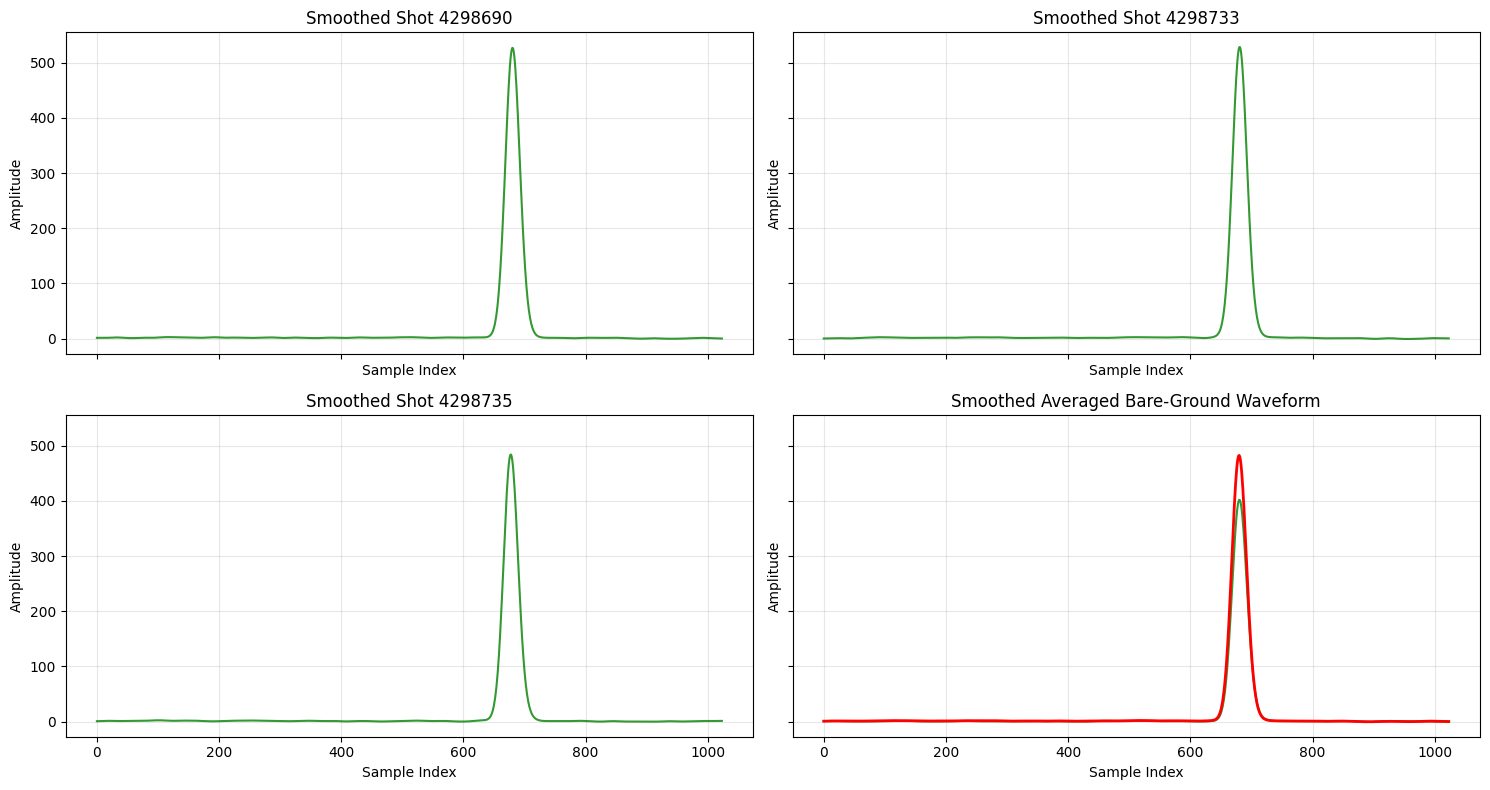

In [4]:
## B. To perform waveform deconvolution, import pure/bare ground return from the waveform;
## From "Qgis" we can see that the bare ground return have following shot number:

gnd_waveforms_shotnums = [4298690, 4298735, 4298733, 4299142, 4298690]

lvis_files = [
    'LVISC1B_GEDI2021_0806_R2112_049718.h5',
    'LVISC1B_GEDI2021_0806_R2112_051257.h5'
]

extracted_rx_waveforms = []
extracted_tx_waveforms = []
extracted_metadata = []

for lvis_file in lvis_files:
    print(f"\nChecking: {lvis_file}")
    
    try:
        with h5py.File(lvis_file, 'r') as lvis_hdf:
            # Load ONLY the shot numbers to find our targets
            shot_numbers = np.array(lvis_hdf['SHOTNUMBER'])
            
            # Create a mask to find where the shot numbers match our list
            mask = np.isin(shot_numbers, gnd_waveforms_shotnums)
            indices = np.where(mask)[0]
            
            if len(indices) > 0:
                print(f"Found {len(indices)} matching shots in this file.")
                
                # h5py requires indices to be sorted for direct extraction
                indices = np.sort(indices) 
                
                # Extract ONLY the required waveforms directly from disk
                rx_waves = lvis_hdf['RXWAVE'][indices]
                tx_waves = lvis_hdf['TXWAVE'][indices]
                
                extracted_rx_waveforms.extend(rx_waves)
                extracted_tx_waveforms.extend(tx_waves)
                
                # Extract metadata including SIGMEAN for noise removal
                for idx in indices:
                    metadata = {
                        'SHOTNUMBER': lvis_hdf['SHOTNUMBER'][idx],
                        'LAT0': lvis_hdf['LAT0'][idx],
                        'LON0': lvis_hdf['LON0'][idx],
                        'Z0': lvis_hdf['Z0'][idx],
                        'SIGMEAN': lvis_hdf['SIGMEAN'][idx],
                        'source_file': lvis_file
                    }
                    extracted_metadata.append(metadata)
            else:
                print("No matching shots found in this file.")
                
    except Exception as e:
        print(f"Error processing {lvis_file}: {e}")

# Convert lists to NumPy arrays
rx_array = np.array(extracted_rx_waveforms)
tx_array = np.array(extracted_tx_waveforms)

print(f"\nTotal extracted ground waveforms: {len(rx_array)}")

## Noise removal and Smoothing 
processed_rx_waveforms = []

for i, rxwave in enumerate(rx_array):
    # Get the specific noise floor for this shot
    sigmean = extracted_metadata[i]['SIGMEAN']
    
    # Remove noise
    rx_clean = np.array(rxwave - sigmean, dtype=np.float64)
    smoothed = gaussian_filter1d(rx_clean, sigma=10.0)
    processed_rx_waveforms.append(smoothed)

processed_rx_array = np.array(processed_rx_waveforms)

# Average the processed waveforms 
if len(processed_rx_array) > 0:
    # Average across the smoothed/denoised shots
    smoothed_avg_bare_ground_rx = np.mean(processed_rx_array, axis=0)  
    avg_bare_ground_tx = np.mean(tx_array, axis=0) 
    df_ground_shots = pd.DataFrame(extracted_metadata)
    
    print("Successfully computed smoothed average bare-ground waveform!")
else:
    print("Could not compute average: no waveforms found.")

## Visualize all these waveforms:

# Create a 2x2 grid for the 3 individual processed shots + 1 averaged shot
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

# Plot the 3 individual processed ground return waveforms
for i, proc_wave in enumerate(processed_rx_array):
    shotnum = extracted_metadata[i]['SHOTNUMBER']
    axes[i].plot(proc_wave, color='g', alpha=0.8)
    axes[i].set_title(f'Smoothed Shot {shotnum}')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
axes[3].plot(smoothed_avg_bare_ground_rx, color='r', linewidth=2)
axes[3].set_title('Smoothed Averaged Bare-Ground Waveform')
axes[3].grid(True, alpha=0.3)
axes[3].set_xlabel('Sample Index')
axes[3].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

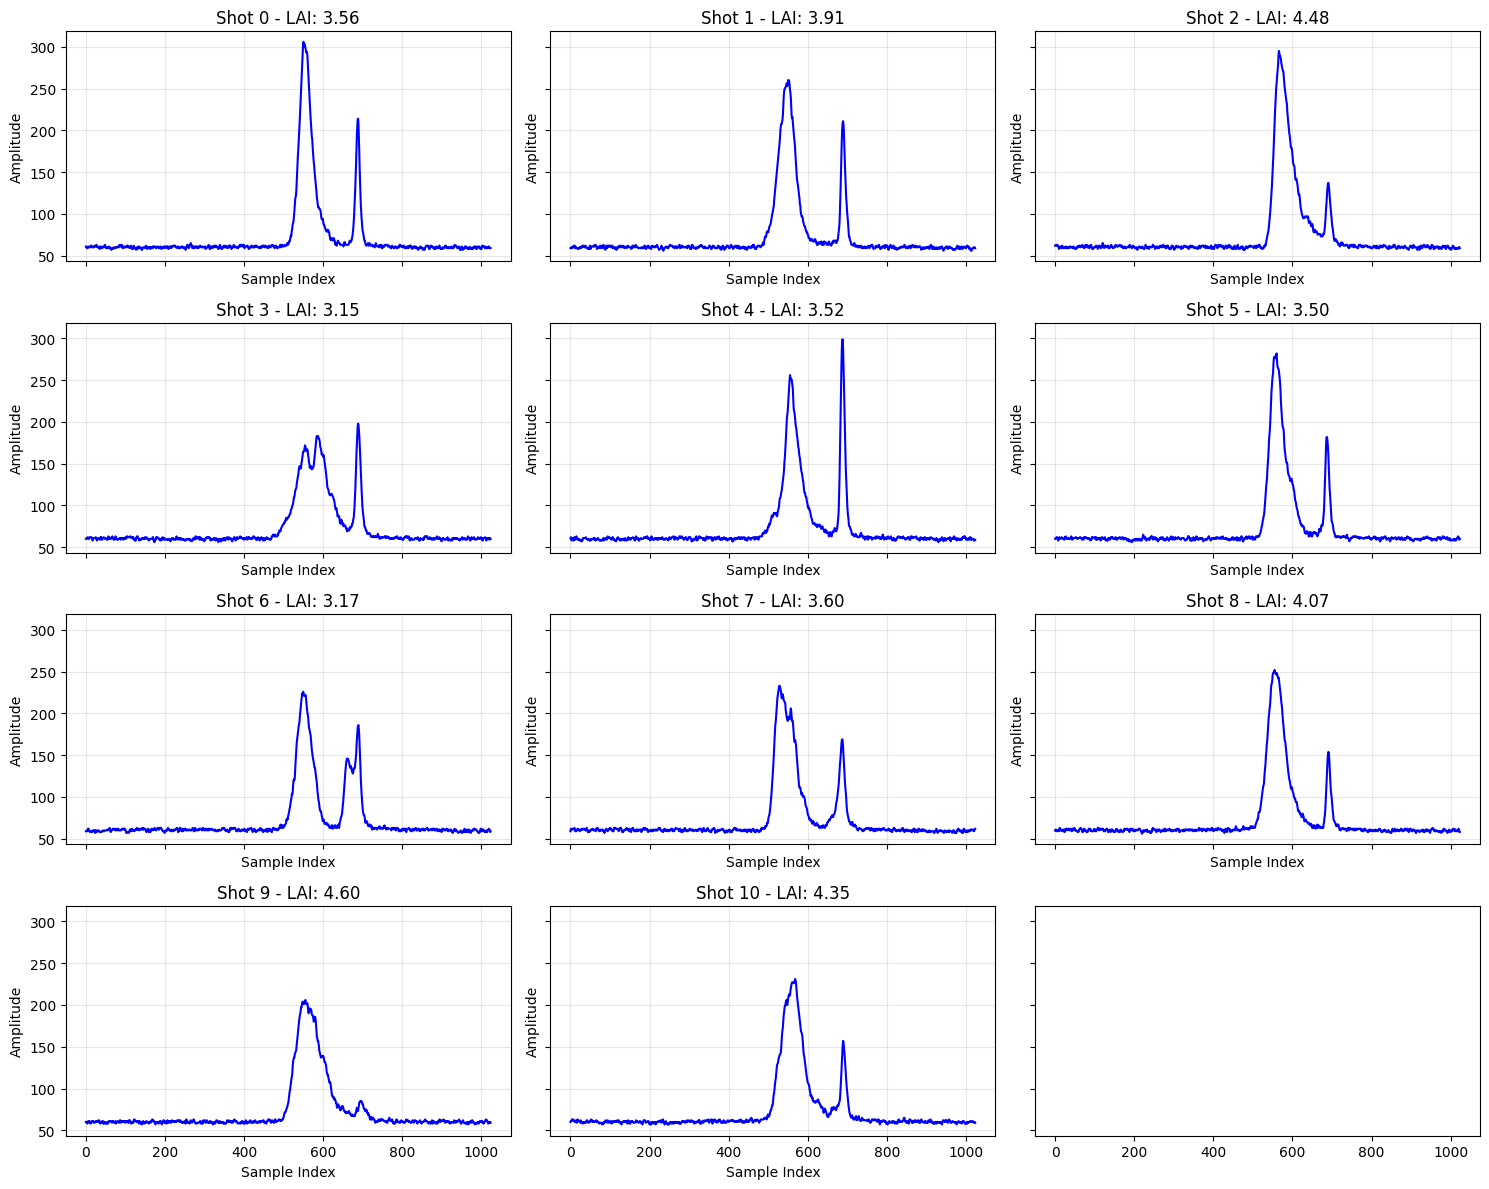

In [5]:
## C. Visualize the raw waveforms along with LAI values

fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, wf in enumerate(waveforms):
    rxwave = np.array(wf['rxwave'], dtype=np.float64)
    lai_value = wf['lai_value']
    axes[i].plot(rxwave, color='b')
    axes[i].set_title(f'Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()


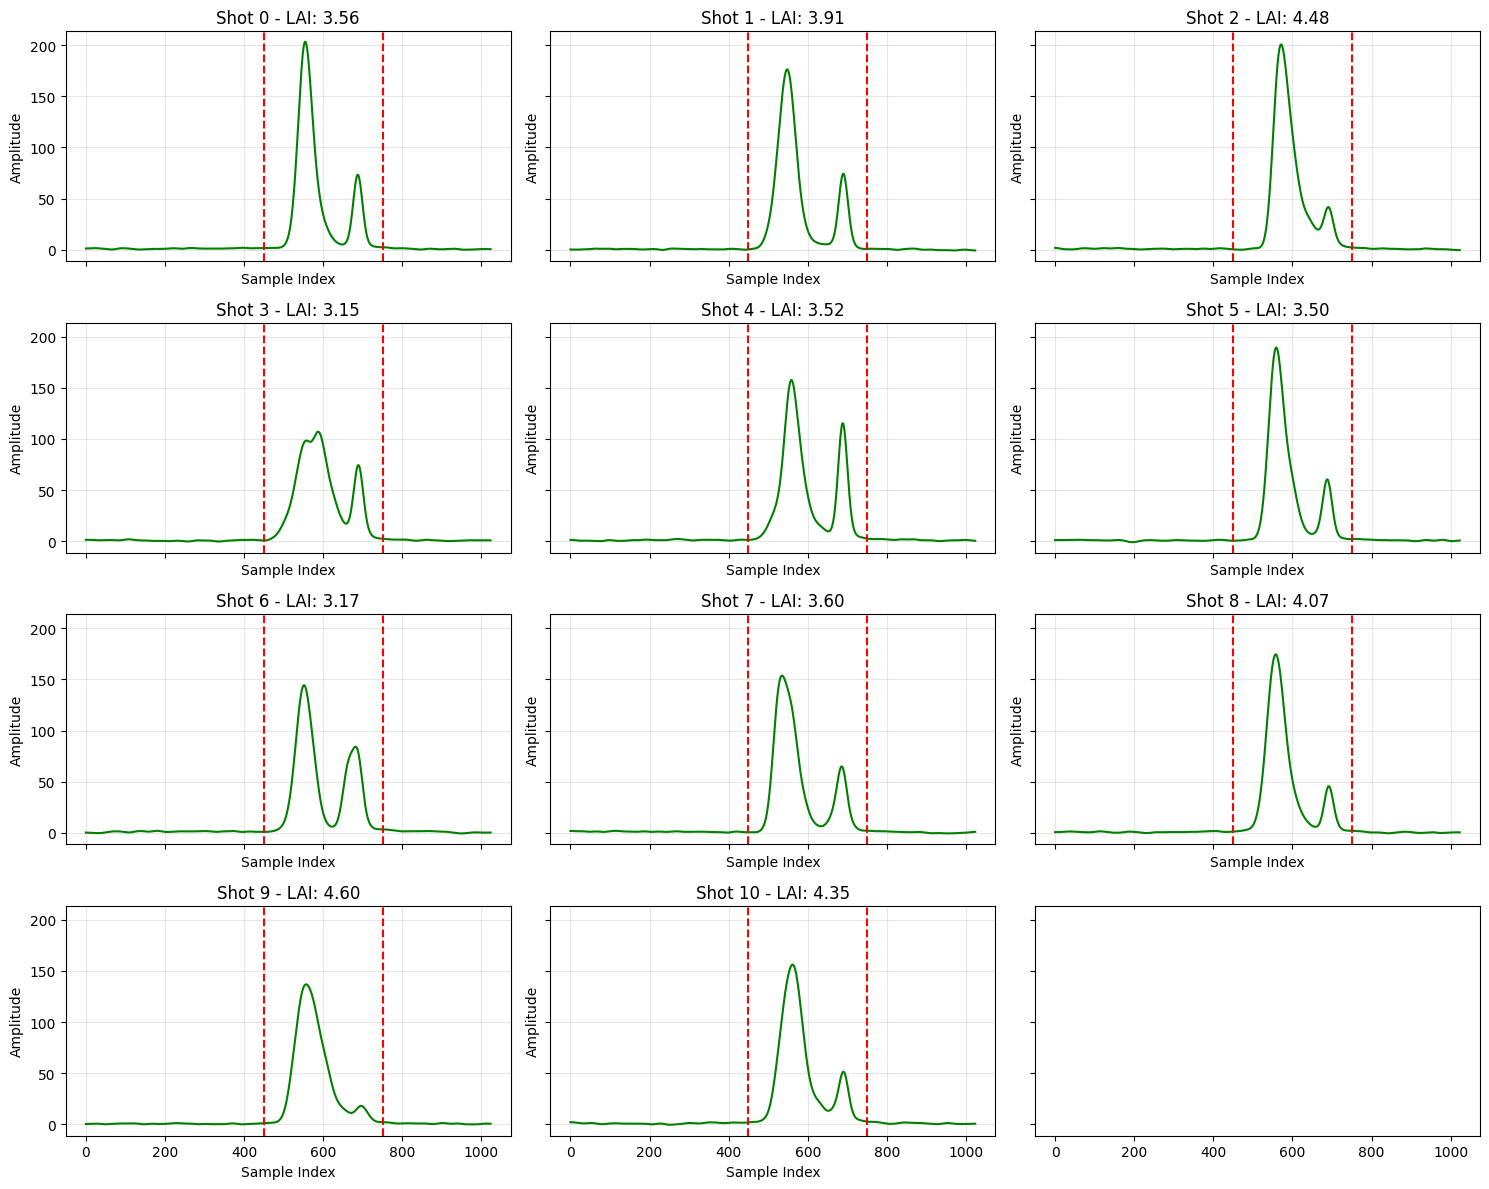

In [6]:
## D. Remove Noise from the raw waveforms for LAI modeling

# Smooth and clip noise
processed = []
lai_values = []

for wf in waveforms:
    rxwave = np.array(wf['rxwave']- wf['SIGMEAN'], dtype=np.float64)
    
    # Smooth
    smoothed = gaussian_filter1d(rxwave, sigma=10.0)
    processed.append(smoothed)

processed = np.array(processed)

# Plot processed waveforms with LAI labels
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (wf, proc) in enumerate(zip(waveforms, processed)):
    lai_value = wf['lai_value']
    lai_values.append(lai_value)
    axes[i].plot(proc, color='g')
    axes[i].set_title(f'Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(450, color='r', linestyle='--')
    axes[i].axvline(750, color='r', linestyle='--')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [7]:
len(processed)

11


Starting Gold Deconvolution...
Deconvolution complete, plotting the deconvolved waveforms...


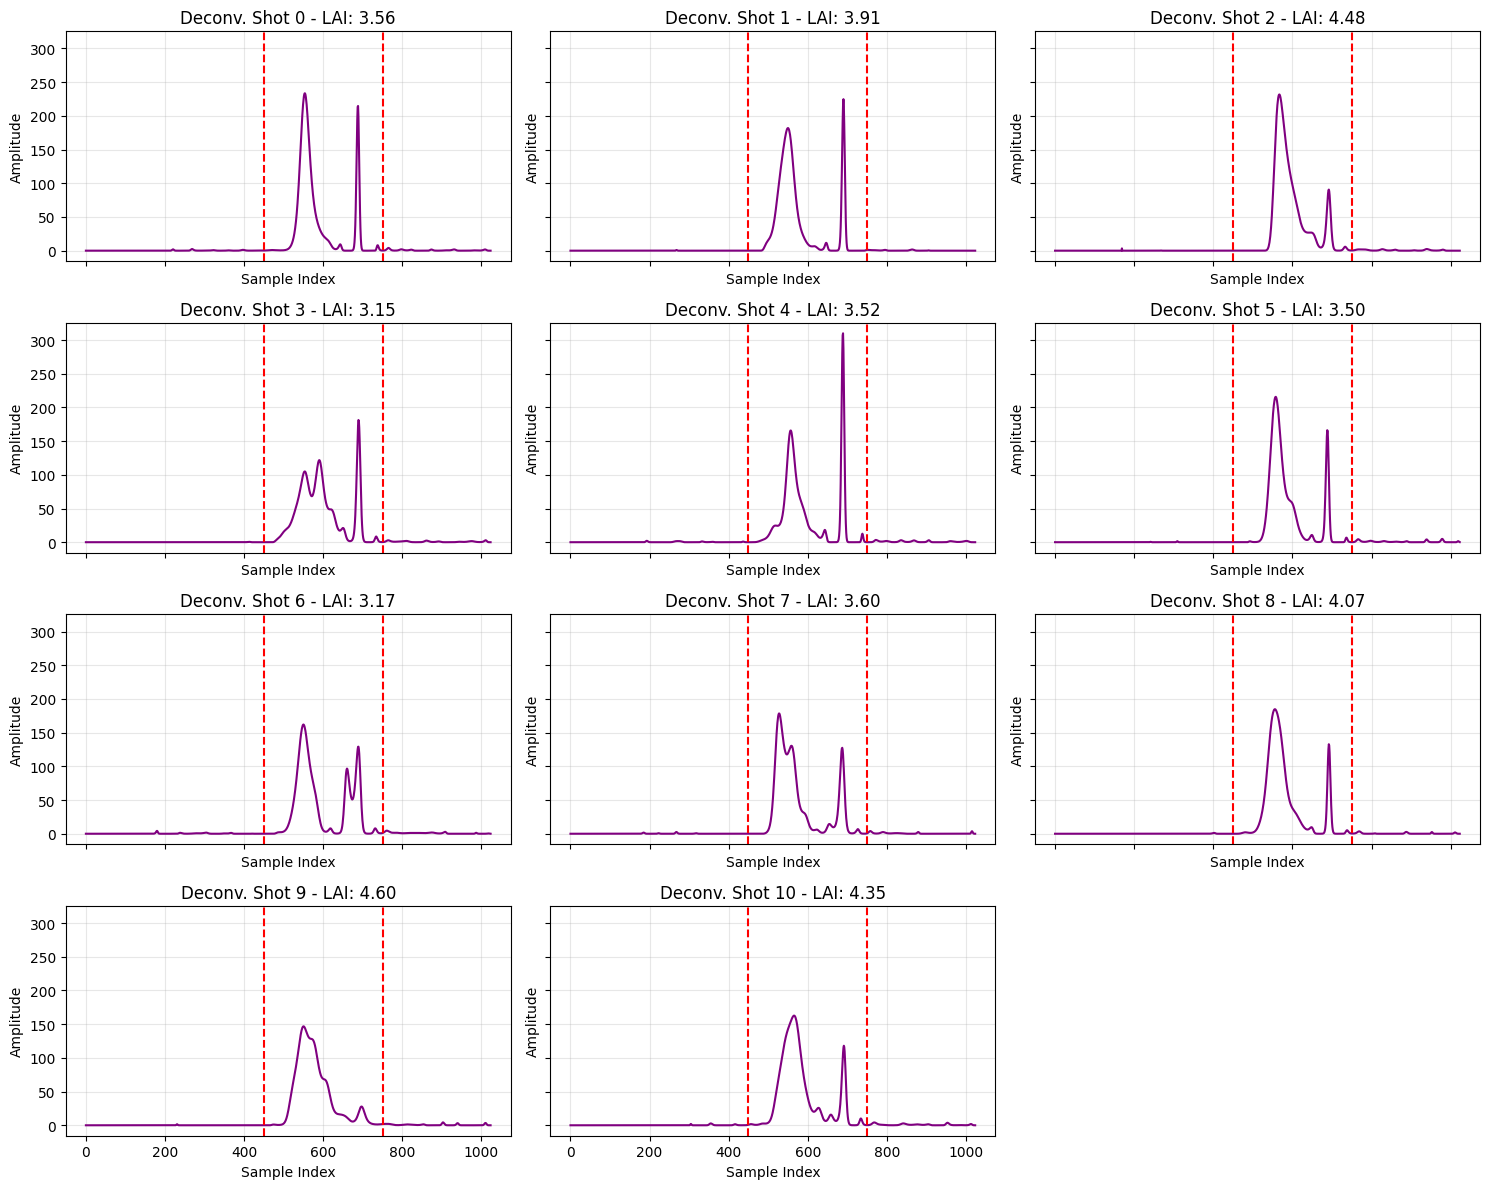

In [8]:
## E. One-Fold Gold-Deconvolution Algorithm:
#  To extract deconvolved waveform using raw smoothed waveforms contained in "processed" array and 
# using "smoothed_avg_bare_ground_rx" as system contribution / system response term and save it in "processed_deconvolved_gold" array.

# Helper function to manually shift the deconvolved signal to correct for alignment
def manual_shift(signal, shift):
    """Manually shift a 1D signal."""
    return np.roll(signal, shift)

# Construct the Response matrix (H) for convolution
def response_matrix(h, len_x):
    """Creates a Response matrix from the filter h for convolution."""
    len_h = len(h)
    H = np.zeros((len_x + len_h - 1, len_x))
    for i in range(len_x): 
        H[i:i + len_h, i] = h
    return H

# Define Boosted one fold gold deconvolution algorithm
def boosted_gold_deconvolution(P_t, R_t, num_iterations=10, num_repetitions=5, boosting_coefficient=1.25, positivity=True):
    y = P_t
    
    # Pad y dynamically so its length perfectly matches H.T's expected dimensions
    target_len = len(P_t) + len(R_t) - 1
    pad_total = target_len - len(P_t)
    pad_left = pad_total // 2
    pad_right = pad_total - pad_left
    y_padded = np.pad(y, (pad_left, pad_right), mode='constant')
    
    # Create matrix H from R_t
    H = response_matrix(R_t, len(P_t))
    
    # Calculate y' = H^T y
    y_prime = H.T @ y_padded
    H_T_H = H.T @ H

    # Initial value of P_delta 
    P_delta = np.ones_like(P_t)

    # Repeat for each repetition
    for r in range(num_repetitions):
        # Repeat for 'n' iterations
        for i in range(num_iterations):
            # Added a tiny epsilon (1e-10) to the denominator to prevent division by zero warnings
            denominator = H_T_H @ P_delta
            denominator[denominator == 0] = 1e-10 
            
            P_delta_est = y_prime / denominator 
            P_delta_new = P_delta_est * P_delta
            P_delta = P_delta_new
            
            # Enforce positivity constraint if enabled
            if positivity:
                P_delta = np.maximum(P_delta, 0)

        if r < num_repetitions - 1:
            P_delta = np.power(P_delta, boosting_coefficient)

    # Energy-based post-scaling to match the original signal energy
    def apply_energy_scaling(P_delta_t_est, P_t):
        energy_P_t = np.sum(np.abs(P_t) ** 2)
        energy_P_delta_t_est = np.sum(np.abs(P_delta_t_est) ** 2)
        scale_factor = np.sqrt(energy_P_t / energy_P_delta_t_est) if energy_P_delta_t_est > 0 else 1.0
        return P_delta_t_est * scale_factor

    # Apply energy-based post-scaling
    P_delta_scaled = apply_energy_scaling(P_delta, P_t)
    
    # Cross-correlation to estimate the shift between P(t) and deconvolved P_delta
    cross_corr = np.correlate(P_t, P_delta_scaled, mode='full')
    shift_index = np.argmax(cross_corr) - len(P_t) + 1
    
    # Apply manual shift to correct alignment using np.roll
    P_delta_shifted = manual_shift(P_delta_scaled, shift=shift_index)
    
    return P_delta_shifted


# Execute
processed_deconvolved_gold = []

print("\nStarting Gold Deconvolution...")
for i, proc_wave in enumerate(processed):
    # Running the deconvolution with boosting_coefficient=1 i.e. no boosting
    deconv_wave = boosted_gold_deconvolution(
        P_t=proc_wave, 
        R_t=smoothed_avg_bare_ground_rx, 
        num_iterations=500,      
        num_repetitions=1, 
        boosting_coefficient=1, 
        positivity=True
    )
    processed_deconvolved_gold.append(deconv_wave)

processed_deconvolved_gold = np.array(processed_deconvolved_gold)
print("Deconvolution complete, plotting the deconvolved waveforms...")

# Plot the results
# Plot deconvolved waveforms with LAI labels
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (wf, deconv) in enumerate(zip(waveforms, processed_deconvolved_gold)):
    lai_value = wf['lai_value']
    axes[i].plot(deconv, color='purple')
    axes[i].set_title(f'Deconv. Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(450, color='r', linestyle='--')
    axes[i].axvline(750, color='r', linestyle='--')
    
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
if len(processed_deconvolved_gold) < len(axes):
    for j in range(len(processed_deconvolved_gold), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


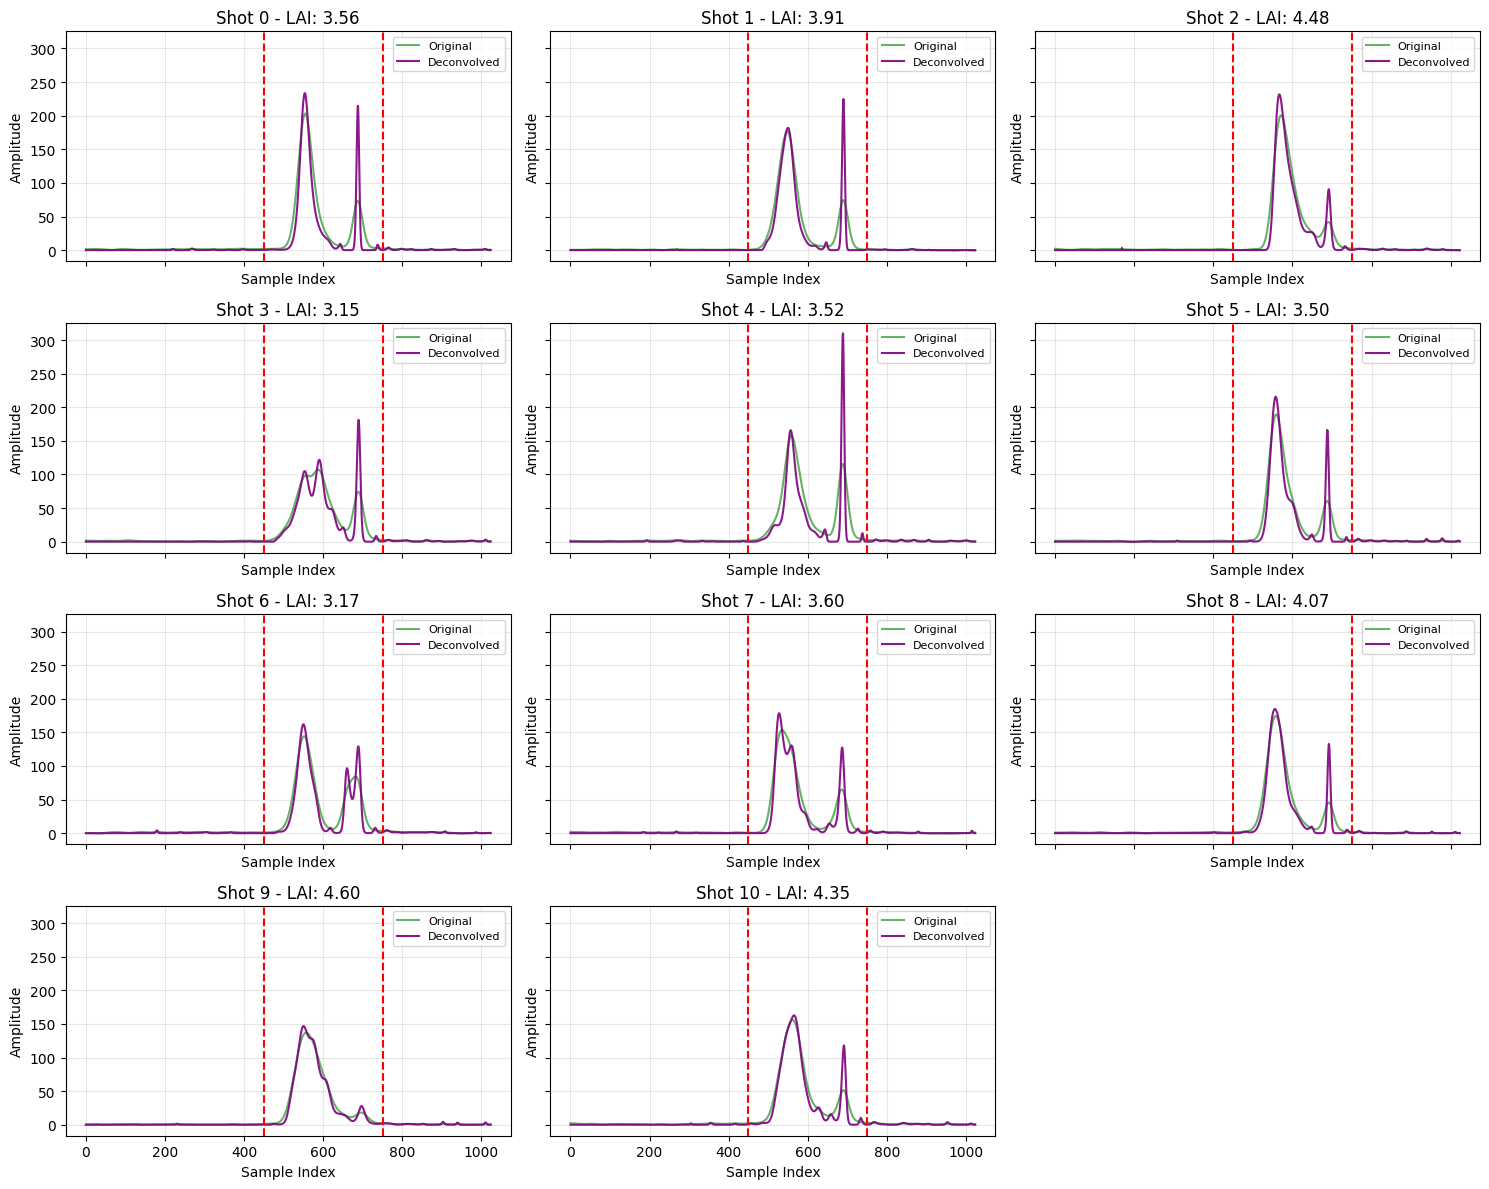

In [9]:
## Plot deconvolved waveforms along with raw waveforms with LAI labels to see how the deconvolution worked.

fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()
for i, (wf, orig_wave, deconv) in enumerate(zip(waveforms, processed, processed_deconvolved_gold)):
    lai_value = wf['lai_value']
    axes[i].plot(orig_wave, color='g', alpha=0.6, linewidth=1.5, label='Original')
    axes[i].plot(deconv, color='purple', alpha=0.9, linewidth=1.5, label='Deconvolved')
    axes[i].set_title(f'Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(450, color='r', linestyle='--')
    axes[i].axvline(750, color='r', linestyle='--')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='upper right', fontsize=8)
if len(processed_deconvolved_gold) < len(axes):
    for j in range(len(processed_deconvolved_gold), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Starting Richardson-Lucy Deconvolution...
RL Deconvolution complete!


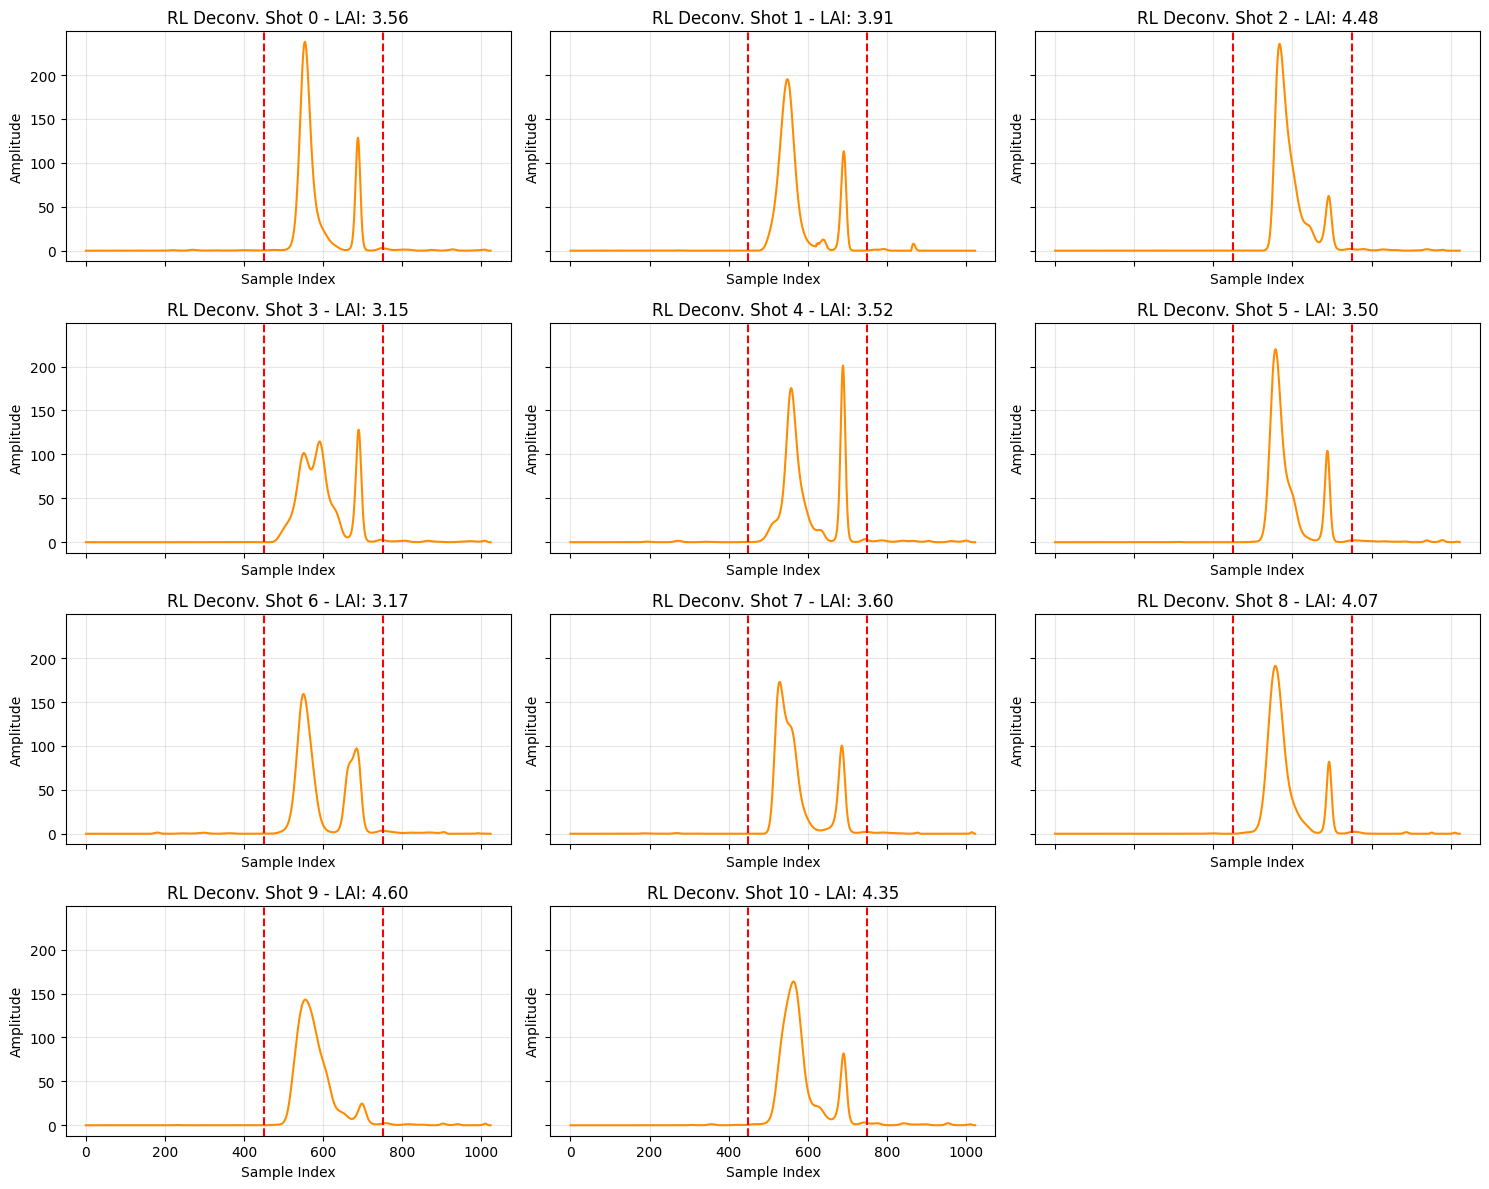

In [10]:
## F. Richardson-Lucy Algorithm for deconvolution:

# Define function
def richardson_lucy_deconvolution_boosted(P_t, R_t, num_iterations, num_repetitions, boosting_coefficient, positivity=True):
    """
    Apply the Richardson-Lucy deconvolution algorithm with boosting.
    """
    
    # Pad the observed waveform to reduce boundary effects
    pad_len = len(R_t) // 2
    P_t_padded = np.pad(P_t, pad_len, mode='constant')

    # Initialize the deconvolved signal with a flat guess (mean of signal is better than 1s)
    P_delta = np.ones_like(P_t_padded) * np.mean(P_t)

    for r in range(num_repetitions):
        # Iterate the RL algorithm
        for i in range(num_iterations):
            
            # Full convolution of the current estimate with the system response
            convolved = fftconvolve(P_delta, R_t, mode='same')
    
            # Compute the ratio P(t) / (R * P_delta)
            ratio = P_t_padded / (convolved + 1e-10)  # Avoid division by zero
    
            # Convolve the ratio with the flipped system response
            correction = fftconvolve(ratio, R_t[::-1], mode='same')
            P_delta *= correction
    
            # Enforce positivity constraint if enabled
            if positivity:
                P_delta = np.maximum(P_delta, 0)
        
        # After n iterations, apply the boosting function to the current solution
        if r < num_repetitions - 1:  
            P_delta = np.power(P_delta, boosting_coefficient)
            
    # Energy-based post-scaling to match the original signal energy
    def apply_energy_scaling(P_delta_t_est, P_t):
        energy_P_t = np.sum(np.abs(P_t) ** 2)
        energy_P_delta_t_est = np.sum(np.abs(P_delta_t_est) ** 2)
        scale_factor = np.sqrt(energy_P_t / energy_P_delta_t_est) if energy_P_delta_t_est > 0 else 1.0
        return P_delta_t_est * scale_factor

    # Trim the padded edges OFF first, before calculating energy scaling
    P_delta_trimmed = P_delta[pad_len:-pad_len]

    # Apply energy-based post-scaling
    P_delta_scaled = apply_energy_scaling(P_delta_trimmed, P_t)
    
    # Cross-correlation to estimate the shift between P(t) and deconvolved P_delta
    cross_corr = np.correlate(P_t, P_delta_scaled, mode='full')
    shift_index = np.argmax(cross_corr) - len(P_t) + 1
    
    # Apply manual shift to correct alignment
    P_delta_shifted = manual_shift(P_delta_scaled, shift=shift_index)
    
    return P_delta_shifted

# Execute 
processed_rl_deconvolved = []

print("\nStarting Richardson-Lucy Deconvolution...")
for i, proc_wave in enumerate(processed):
    # RL converges faster than Gold, 10-150 iterations is usually a good sweet spot
    deconv_wave = richardson_lucy_deconvolution_boosted(
        P_t=proc_wave, 
        R_t=smoothed_avg_bare_ground_rx, 
        num_iterations=25,      
        num_repetitions=1, 
        boosting_coefficient=1, 
        positivity=True
    )
    processed_rl_deconvolved.append(deconv_wave)

processed_deconvolved_rl = np.array(processed_rl_deconvolved)
print("RL Deconvolution complete!")

## Plot the results
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (wf, deconv) in enumerate(zip(waveforms, processed_deconvolved_rl)):
    lai_value = wf['lai_value']
    axes[i].plot(deconv, color='darkorange')
    axes[i].set_title(f'RL Deconv. Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(450, color='r', linestyle='--')
    axes[i].axvline(750, color='r', linestyle='--')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
if len(processed_deconvolved_rl) < len(axes):
    for j in range(len(processed_deconvolved_rl), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


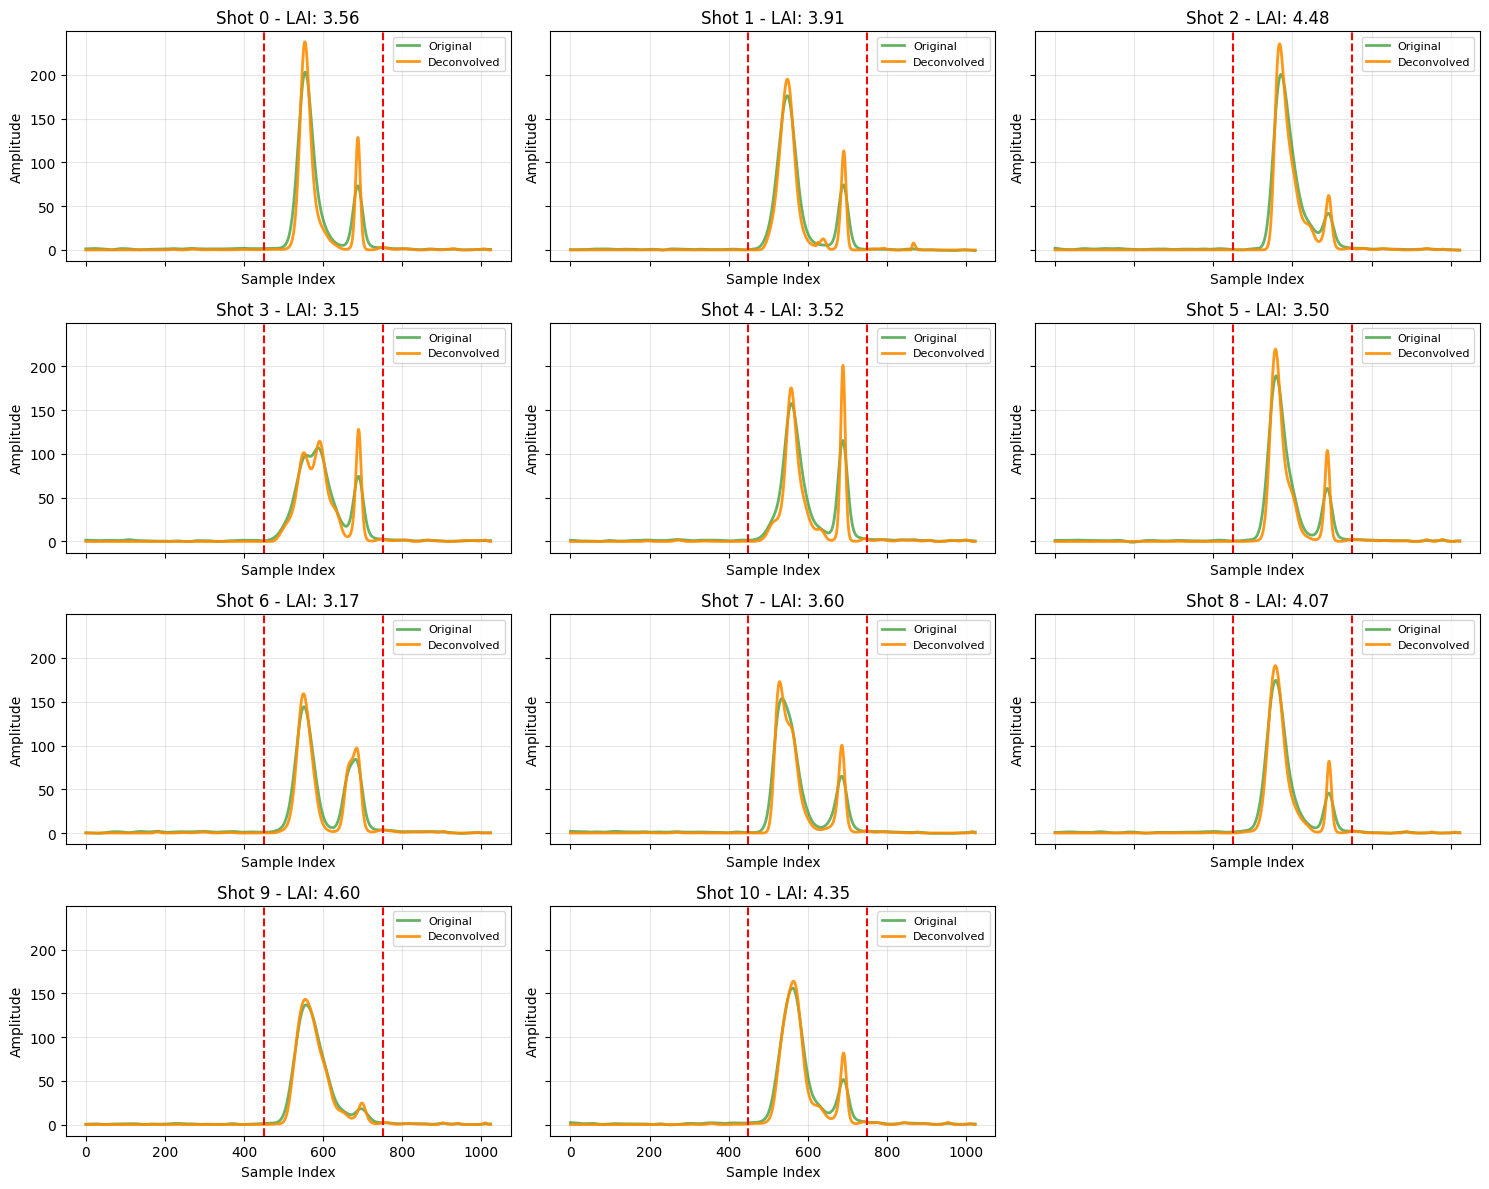

In [11]:
## Again plot deconvolved waveforms along with raw waveforms with LAI labels to see how the deconvolution worked.

fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()
for i, (wf, orig_wave, deconv) in enumerate(zip(waveforms, processed, processed_deconvolved_rl)):
    lai_value = wf['lai_value']
    axes[i].plot(orig_wave, color='g', alpha=0.6, linewidth=2, label='Original')
    axes[i].plot(deconv, color='darkorange', alpha=0.9, linewidth=2, label='Deconvolved')
    axes[i].set_title(f'Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(450, color='r', linestyle='--')
    axes[i].axvline(750, color='r', linestyle='--')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='upper right', fontsize=8)
if len(processed_deconvolved_gold) < len(axes):
    for j in range(len(processed_deconvolved_gold), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [12]:
## !!Important Block: Change data here to get the results:

processed_raw = processed
processed_deconvolved = processed_deconvolved_gold # for 'Gold' deconvolved waveforms, do similar for 'rl' algorithm

# Clip waveforms to bins 400-900: Since most information is in this region
# raw
clipped_waveforms_raw = processed_raw[:, 400:800]
final_raw_waveforms = clipped_waveforms_raw

# deconvolved
clipped_waveforms_decon = processed_deconvolved[:, 400:800]
final_decon_waveforms = clipped_waveforms_decon


##### **1. Physical model**

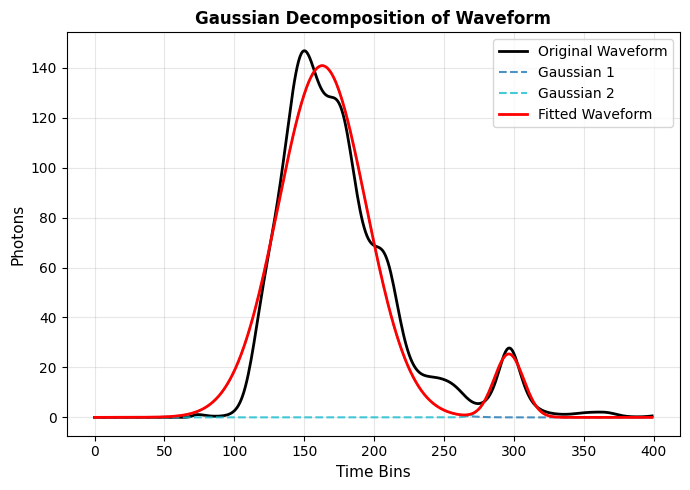


Detected Gaussian Components:
  Component 1: Amplitude=140.83, Mean=162.93, StdDev=31.28
  Component 2: Amplitude=25.40, Mean=296.48, StdDev=10.51


In [14]:
## G. Gaussian decomposition of the waveform LiDAR

def multi_gaussian(x, *params):
    """Evaluate sum of Gaussians."""
    y = np.zeros_like(x, dtype=float)
    x = x.astype(float)
    for i in range(0, len(params), 3):
        amplitude = params[i]
        mean = params[i + 1]
        stddev = params[i + 2]
        y += amplitude * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))
    return y


# Gaussian Decomposition Function
def decompose_waveform(waveform, prominence_factor=0.15, min_width=1, max_width=100):
    
    """Decompose waveform into Gaussian components."""
    x_data = np.arange(len(waveform))
    waveform = np.array(waveform, dtype=float)
    smoothed = waveform.copy()

    # Peak detection
    max_amplitude = np.max(waveform)
    prominence_threshold = max_amplitude * prominence_factor
    peaks, properties = find_peaks(
        smoothed,
        height=prominence_threshold,
        prominence=prominence_threshold * 0.5,
        distance=5,
        width=(min_width, max_width)
    )
    
    if len(peaks) == 0:
        prominence_threshold *= 0.25
        peaks, properties = find_peaks(
            smoothed,
            height=prominence_threshold,
            prominence=prominence_threshold * 0.5,
            distance=2,
            width=(min_width, max_width)
        )
    
    if len(peaks) == 0:
        return None
    
    # Initial parameters and bounds
    initial_params = []
    bounds_lower = []
    bounds_upper = []
    
    for idx, peak in enumerate(peaks):
        amplitude_guess = waveform[peak]
        mean_guess = float(peak)
        width = properties['widths'][idx] if 'widths' in properties else 2.0
        stddev_guess = max(0.25, width/2.355)
        
        initial_params.extend([amplitude_guess, mean_guess, stddev_guess])
        bounds_lower.extend([amplitude_guess * 0.1, peak - 20, 0.3])
        bounds_upper.extend([amplitude_guess * 2.5, peak + 20, 50.0])
    
    # Fit with bounds
    x_data_float = x_data.astype(float)
    
    try:
        params, _ = curve_fit(
            multi_gaussian,
            x_data_float,
            waveform,
            p0=initial_params,
            bounds=(bounds_lower, bounds_upper),
            maxfev=5000,
            ftol=1e-6
        )
        return params
    except RuntimeError as e:
        print(f"Gaussian fitting did not converge: {e}")
        return None


def plot_waveform_and_gaussians(waveform, params, title='Gaussian Decomposition of Waveform'):
    """Plot original waveform, fitted components, and their sum."""
    x_data = np.arange(len(waveform))
    
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(x_data, waveform, label='Original Waveform', color='black', linewidth=2)
    
    colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(params) // 3)))
    for i in range(0, len(params), 3):
        amplitude = params[i]
        mean = params[i + 1]
        stddev = params[i + 2]
        gaussian_curve = multi_gaussian(x_data, amplitude, mean, stddev)
        ax.plot(x_data, gaussian_curve, '--', label=f'Gaussian {i//3 + 1}', 
                color=colors[i//3], linewidth=1.5, alpha=0.8)
    
    fitted_waveform = multi_gaussian(x_data, *params)
    ax.plot(x_data, fitted_waveform, label='Fitted Waveform', color='red', linewidth=2, alpha=1)
    ax.set_xlabel('Time Bins', fontsize=11)
    ax.set_ylabel('Photons', fontsize=11)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Example usage
waveform = final_decon_waveforms[9]
params = decompose_waveform(waveform, prominence_factor=0.15)
if params is not None:
    plot_waveform_and_gaussians(waveform, params)
    print("\nDetected Gaussian Components:")
    for i in range(0, len(params), 3):
        print(f"  Component {i//3 + 1}: Amplitude={params[i]:.2f}, Mean={params[i+1]:.2f}, StdDev={params[i+2]:.2f}")


# Determine Gap-Probability from decomposed waveforms
def gap_probability(params, rho_ratio=2.5):
    """Calculate gap probability from Gaussian parameters."""
    if params is None or len(params) == 0:
        return np.nan
    
    num_gaussians = len(params) // 3
    veg_energy = 0.0
    ground_energy = 0.0

    for i in range(num_gaussians):
        amplitude = params[i * 3]
        stddev = params[i * 3 + 2]
        
        gaussian_energy = amplitude
        
        if i == num_gaussians - 1:
            ground_energy = gaussian_energy
        else:
            veg_energy += gaussian_energy

    denominator = (rho_ratio * veg_energy) + ground_energy
    
    if denominator == 0:
        return np.nan
    
    gap_prob = ground_energy / denominator
    
    return np.clip(gap_prob, 0.0, 1.0)


# Calculate gap_probability for all waveforms
gap_data_float64 = []

for waveform in final_decon_waveforms:
    params = decompose_waveform(waveform)
    
    if params is not None:
        gap_probab = gap_probability(params, rho_ratio=2.5)
        gap_data_float64.append(gap_probab)
    else:
        gap_data_float64.append(np.nan)

# Convert to numpy array
gap_data = np.array(gap_data_float64)

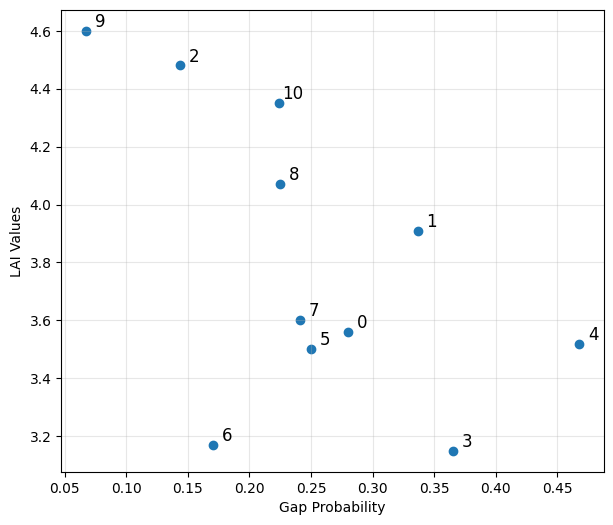

In [15]:
## Plot LAI vs -log(Gap Probability)

x = gap_data
y = lai_values

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y)
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.annotate(str(i), (xi, yi), textcoords="offset points", xytext=(10, 3), ha='center', fontsize=12)

plt.xlabel('Gap Probability')
plt.ylabel('LAI Values')
plt.grid(True, alpha=0.3)
plt.show()


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     5.944
Date:                Thu, 26 Feb 2026   Prob (F-statistic):             0.0375
Time:                        21:16:59   Log-Likelihood:                -4.8313
No. Observations:                  11   AIC:                             13.66
Df Residuals:                       9   BIC:                             14.46
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9005      0.393      7.371      0.0

/Users/rbcis/miniconda3/envs/main/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)


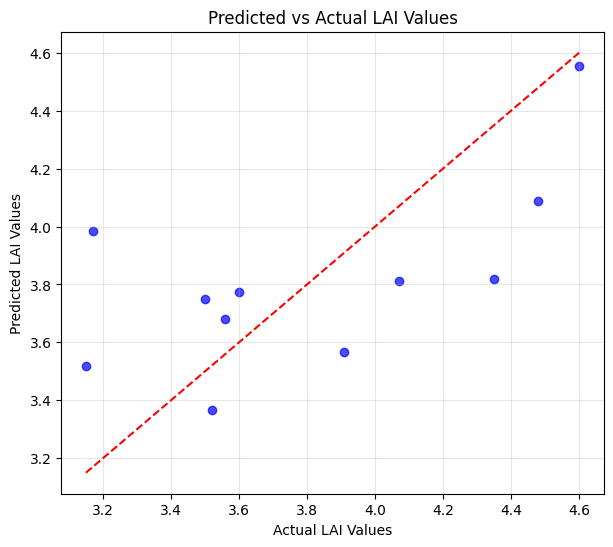

In [16]:
## H. OLS Regression: LAI vs -log(Gap Probability)

import statsmodels.api as sm

# Ensure data is in numpy array format
X = -np.log(x).reshape(1,-1)  # Gap Probability
Y = y  # LAI
X = np.column_stack(X)
X = sm.add_constant(X)  # Adds intercept term

# Fit the regression model
model = sm.OLS(Y, X).fit()

# Print model summary
print(model.summary())

## Plot predicted vs actual LAI values
predicted_lai = model.predict(X)
plt.figure(figsize=(7, 6))
plt.scatter(Y, predicted_lai, color='blue', alpha=0.7)
plt.plot([min(Y), max(Y)], [min(Y), max(Y)], color='red', linestyle='--')
plt.xlabel('Actual LAI Values')
plt.ylabel('Predicted LAI Values')
plt.title('Predicted vs Actual LAI Values')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
## Performance metrics

adj_R2 = model.rsquared_adj
R2 = model.rsquared
MSE = model.mse_resid
RMSE = np.sqrt(MSE)
MAE = np.mean(np.abs(model.resid))
pearson_r = np.corrcoef(model.fittedvalues, Y)[0, 1]


# Print results
print(f"Number of Samples: {len(Y)}")
print(f"Adjusted R²: {adj_R2:.3f}")
print(f"R²: {R2:.3f}")
print(f"MSE: {MSE:.3f}")
print(f"RMSE: {RMSE:.3f}")
print(f"MAE: {MAE:.3f}")
print(f"Pearson's r: {pearson_r:.3f}")

Number of Samples: 11
Adjusted R²: 0.331
R²: 0.398
MSE: 0.172
RMSE: 0.415
MAE: 0.313
Pearson's r: 0.631


In [18]:
## I. Ridge regularized regression

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut

# Prepare data
X1 = -np.log(gap_data)  # -log(Gap Probability)
Y = np.array(lai_values)  # LAI
X_gf = X1.reshape(-1, 1)
X_scaled_gf = X_gf.copy()

# Ridge Regression Model
ridge_model_gf = Ridge(alpha=0.1)
ridge_model_gf.fit(X_scaled_gf, Y)

# Predictions
Y_pred_gf = ridge_model_gf.predict(X_scaled_gf)

# Metrics
r2_gf_main = r2_score(Y, Y_pred_gf)
rmse_gf_main = np.sqrt(mean_squared_error(Y, Y_pred_gf))
pearson_r_gf_main = np.corrcoef(Y, Y_pred_gf)[0, 1]

print("="*50)
print("RIDGE REGRESSION: -log(Gap Probability) → LAI")
print("="*50)
print(f"Intercept:  {ridge_model_gf.intercept_:.4f}")
print(f"Coef:       {ridge_model_gf.coef_[0]:.4f}")
print(f"\nR²:         {r2_gf_main:.4f}")
print(f"RMSE:       {rmse_gf_main:.4f}")
print(f"Pearson r:  {pearson_r_gf_main:.4f}")

# Try different alpha values to find best
alphas = [0.1, 0.5, 1.0, 2.0, 5.0]
print(f"\nTuning Ridge alpha:")
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_scaled_gf, Y)
    Y_pred_gf = model.predict(X_scaled_gf)
    r2_gf = r2_score(Y, Y_pred_gf)
    rmse_gf = np.sqrt(mean_squared_error(Y, Y_pred_gf))
    print(f"alpha={alpha:.1f}: R²={r2_gf:.4f}, RMSE={rmse_gf:.4f}, MSE={rmse_gf**2:.4f}")

## Overfit check
loo = LeaveOneOut()
mse_cv = []

for train_idx, test_idx in loo.split(X_scaled_gf):
    X_train, X_test = X_scaled_gf[train_idx], X_scaled_gf[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    
    ridge_fold = Ridge(alpha=1.0)
    ridge_fold.fit(X_train, Y_train)
    y_pred = ridge_fold.predict(X_test)
    mse_cv.append((y_pred[0] - Y_test[0])**2)

rmse_loocv = np.sqrt(np.mean(mse_cv))
rmse_train = rmse_gf
print(f"\n{'='*50}")
print("OVERFITTING CHECK")
print(f"{'='*50}")
print(f"Training RMSE:  {rmse_train:.4f}")
print(f"LOOCV RMSE:     {rmse_loocv:.4f}")
print(f"LOOCV MSE:     {rmse_loocv**2:.4f}")
print(f"Difference:     {rmse_loocv - rmse_train:+.4f}")

if rmse_loocv - rmse_train < 0.1:
    print("✓ No significant overfitting")
else:
    print("⚠️  Overfitting detected")

RIDGE REGRESSION: -log(Gap Probability) → LAI
Intercept:  2.9326
Coef:       0.5907

R²:         0.3973
RMSE:       0.3756
Pearson r:  0.6307

Tuning Ridge alpha:
alpha=0.1: R²=0.3973, RMSE=0.3756, MSE=0.1410
alpha=0.5: R²=0.3882, RMSE=0.3784, MSE=0.1432
alpha=1.0: R²=0.3692, RMSE=0.3842, MSE=0.1476
alpha=2.0: R²=0.3267, RMSE=0.3970, MSE=0.1576
alpha=5.0: R²=0.2314, RMSE=0.4241, MSE=0.1799

OVERFITTING CHECK
Training RMSE:  0.4241
LOOCV RMSE:     0.4511
LOOCV MSE:     0.2035
Difference:     +0.0270
✓ No significant overfitting


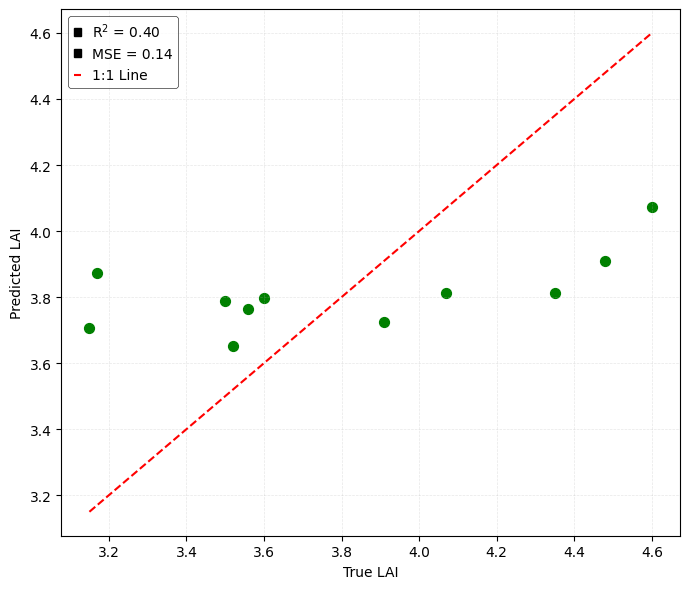

In [19]:
## Plot the performace IEEE style.

from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import matplotlib.patches as mpatches

# Set default rcParams using the extracted font name
# plt.rcParams.update({
#     "font.family": 'Times New Roman',
#     "font.size": 14,
#     "figure.dpi": 300,
#     "axes.labelsize": 14,
#     "axes.linewidth": 0.75,
#     "lines.linewidth": 0.75,
#     "legend.fontsize": 10,
#     "xtick.labelsize": 10,
#     "ytick.labelsize": 10
# })

# Plot predicted vs actual LAI values for Ridge Regression
plt.figure(figsize=(7, 6))
plt.scatter(Y, Y_pred_gf, alpha=1, color='green', s=50, edgecolors='green', linewidth=1)
line1to1 = plt.plot([min(Y), max(Y)], [min(Y), max(Y)], color='red', linestyle='--', label='1:1 Line')[0]
plt.xlabel('True LAI')
plt.ylabel('Predicted LAI')
# plt.title('Ridge Regression: Predicted vs Actual LAI Values')
plt.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
pms = [
    mpatches.Patch(color='black', label=f'R$^2$ = {r2_gf_main:.2f}'),
    mpatches.Patch(color='black', label=f'MSE = {rmse_gf_main**2:.2f}'), line1to1
]
legend = plt.legend(handles=pms, loc='upper left',
                     handleheight=0.5, handlelength=0.5)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.5)
plt.tight_layout()
# plt.savefig('../../Real_LVIS_samples_test_GF_model_v2.pdf', dpi=300, bbox_inches='tight', format='pdf')
# plt.savefig('../../Real_LVIS_samples_test_GF_model_v2.png', dpi=300, bbox_inches='tight', format='png')
plt.show()


##### **2. Our Model**  
##### **See Bhatta et al. (2025) for details.**

In [20]:
## J. Calculate Centroid and Total Return Energy

import numpy as np

# Create a reusable function for the metric extraction
def calculate_centroid_and_energy(waveforms):
    centroids = []
    RWE = []
    
    # Process each waveform
    for waveform in waveforms:
        # Noise removal
        waveform = np.array(waveform, dtype=np.float64)
        waveform_corrected = np.maximum(waveform - np.min(waveform), 0)
        
        # Define the position of each time bin (assuming regular sampling)
        x = np.arange(len(waveform_corrected))
        
        # Calculate total return energy (sum of intensities)
        total_energy = np.sum(waveform_corrected)
        RWE.append(total_energy)
        
        # Check if there's any energy in the waveform to avoid division by zero
        if total_energy == 0:
            centroids.append(None)
            continue
        
        # Centroid calculation (Intensity-weighted average position)
        C = np.sum(x * waveform_corrected) / total_energy
        centroids.append(C)
        
    return np.array(centroids), np.array(RWE)

# Raw
centroids_raw, RWE_raw = calculate_centroid_and_energy(final_raw_waveforms)
print(f"Processed {len(RWE_raw)} raw waveforms.")

# Deconvolved
centroids_decon, RWE_decon = calculate_centroid_and_energy(final_decon_waveforms)
print(f"Processed {len(RWE_decon)} deconvolved waveforms.")

Processed 11 raw waveforms.
Processed 11 deconvolved waveforms.


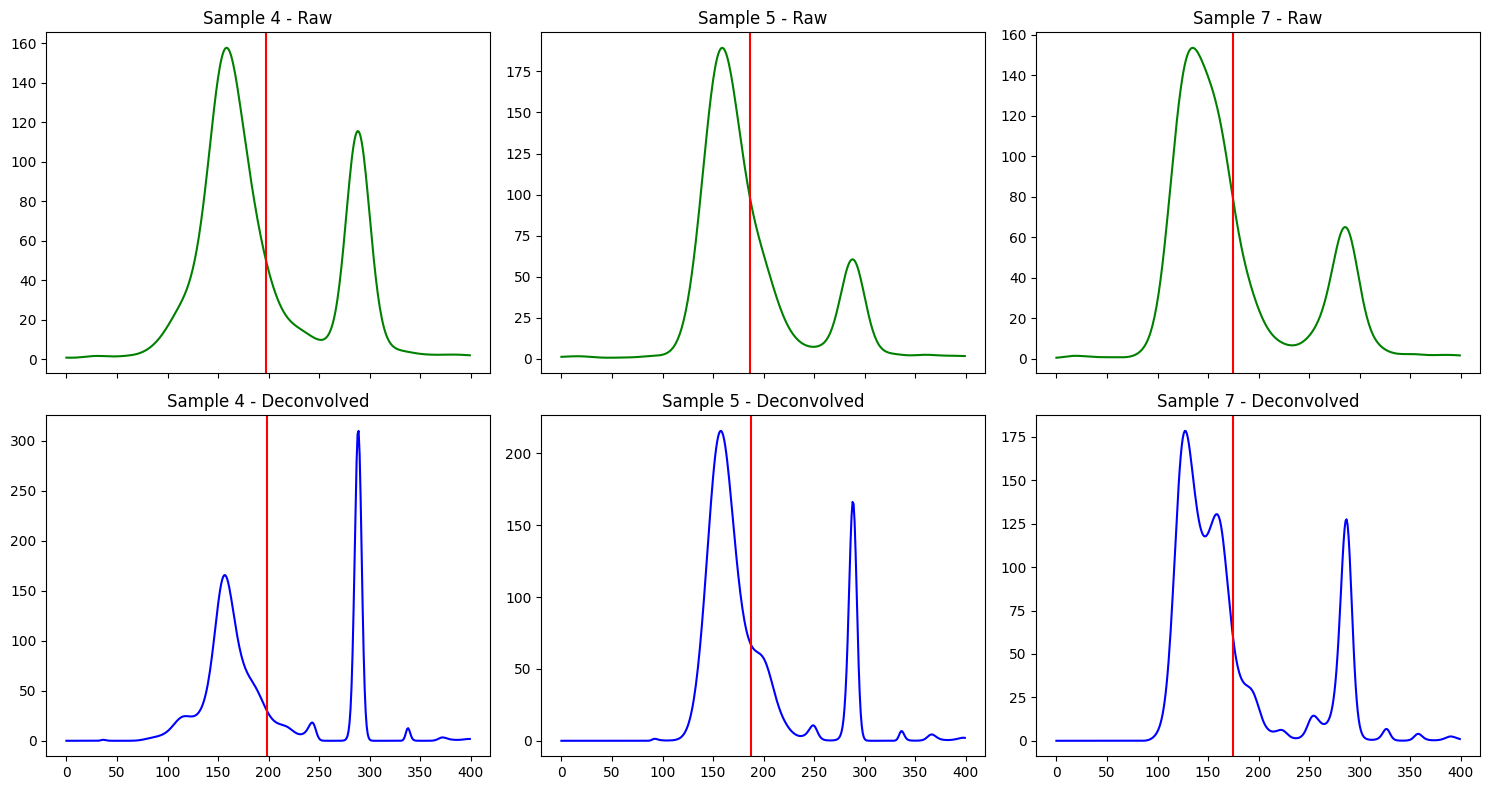

In [21]:
## Plot sample centroids

plot_indices = [4, 5, 7]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

for i, idx in enumerate(plot_indices):
    # Raw samples (Top Row)
    axes[0, i].plot(final_raw_waveforms[idx], color='g')
    if centroids_raw[idx] is not None:
        axes[0, i].axvline(centroids_raw[idx], color='r')
    axes[0, i].set_title(f'Sample {idx} - Raw')
    
    # Deconvolved samples (Bottom Row)
    axes[1, i].plot(final_decon_waveforms[idx], color='b')
    if centroids_decon[idx] is not None:
        axes[1, i].axvline(centroids_decon[idx], color='r')
    axes[1, i].set_title(f'Sample {idx} - Deconvolved')

plt.tight_layout()
plt.show()

In [22]:
## K. Calculate Gini coefficient metric

def calculate_gini_coeff(y, interval_width=0.05):
    # Ensure F(y) starts at 0 and ends at 1
    y = np.array(y)
    if y[0] != 0: y = np.insert(y, 0, 0)
    if y[-1] != 1: y = np.append(y, 1)
    
    k = len(y)
    n = k - 1
    correction_factor = n / (n - 1)
    
    # Compute area under the Lorenz curve 
    area = 0
    for i in range(1, k):
        area += ((y[i] + y[i-1]) / 2) * interval_width
    
    gini_coefficient = correction_factor * (0.5 - area)
    return gini_coefficient

def process_gini(waveforms_list):
    gini_results = []
    for waveform in waveforms_list:
        waveform_corrected = np.maximum(waveform - np.min(waveform), 0)
        peaks, _ = find_peaks(waveform_corrected, height=np.max(waveform_corrected) * 0.05)
        derivative = np.diff(waveform_corrected)
        
        first_inflection_point, last_inflection_point = None, None

        if len(peaks) > 0:
            last_peak = peaks[-1]
            for i in range(last_peak + 1, len(derivative)):
                if derivative[i] == 0.0:
                    last_inflection_point = i
                    break
            for i in range(len(derivative)):
                if derivative[i] > 0.0:
                    first_inflection_point = i
                    break

        if first_inflection_point is not None and last_inflection_point is not None:
            waveform_clipped = waveform_corrected[first_inflection_point:last_inflection_point+1]
        else:
            waveform_clipped = waveform_corrected

        waveform_reversed = waveform_clipped[::-1]
        cumulative_energy = np.cumsum(waveform_reversed)
        total_energy = np.sum(waveform_reversed)

        if total_energy <= 0:
            gini_results.append(0)
            continue

        s = 0.05
        RH_levels = np.arange(0, 1 + s, s)
        RHs = np.array([np.searchsorted(cumulative_energy, level * total_energy) for level in RH_levels]) 
        
        lorentz_height_values = np.cumsum(RHs * 0.15)
        if np.max(lorentz_height_values) > 0:
            lorentz_height_values = lorentz_height_values / np.max(lorentz_height_values)
            GC = calculate_gini_coeff(lorentz_height_values, s)
        else:
            GC = 0
            
        gini_results.append(GC)
    return np.array(gini_results)

# Calculate for Raw
Gini_coefficients_raw = process_gini(final_raw_waveforms)

# Calculate for Deconvolved
Gini_coefficients_decon = process_gini(final_decon_waveforms)

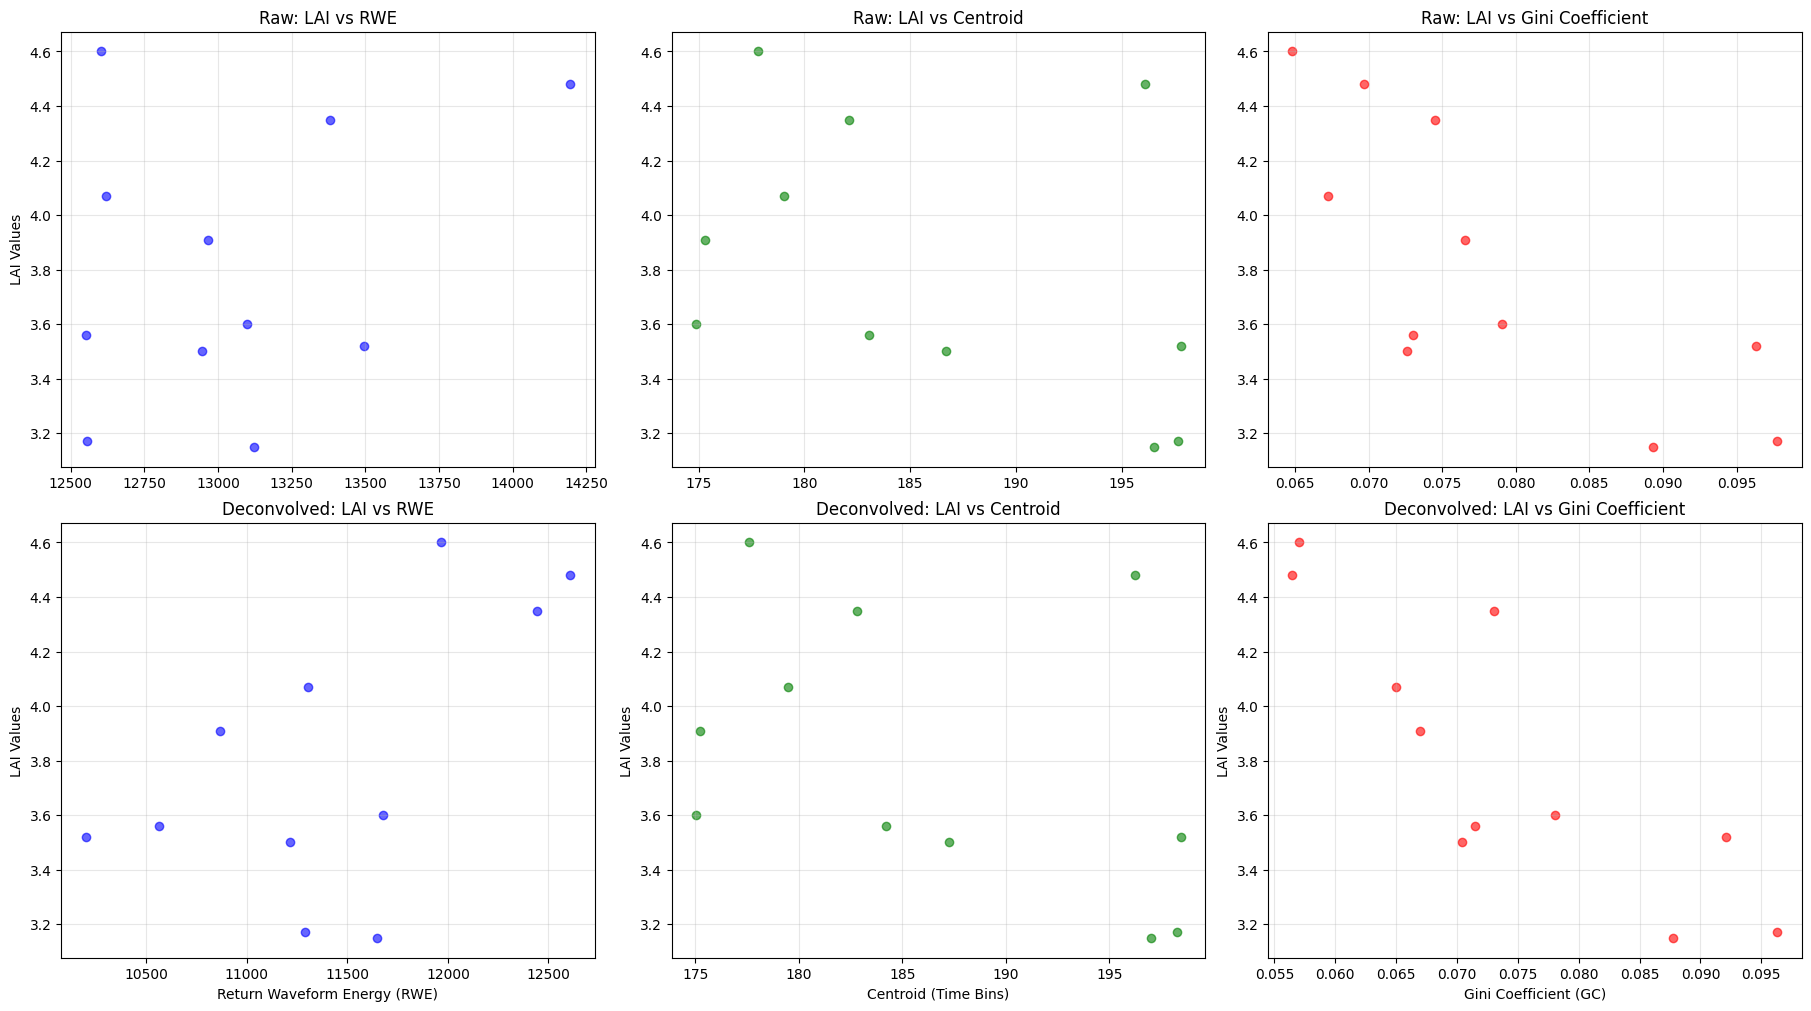

In [23]:
## Plot LAI vs RWE, Centroid, Gini Coefficient

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

# Raw data
axes[0, 0].scatter(RWE_raw, lai_values, color='b', alpha=0.6)
axes[0, 0].set_ylabel('LAI Values')
axes[0, 0].set_title('Raw: LAI vs RWE')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(centroids_raw, lai_values, color='g', alpha=0.6)
axes[0, 1].set_title('Raw: LAI vs Centroid')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(Gini_coefficients_raw, lai_values, color='r', alpha=0.6)
axes[0, 2].set_title('Raw: LAI vs Gini Coefficient')
axes[0, 2].grid(True, alpha=0.3)

# Deconvolved data
axes[1, 0].scatter(RWE_decon, lai_values, color='b', alpha=0.6)
axes[1, 0].set_xlabel('Return Waveform Energy (RWE)')
axes[1, 0].set_ylabel('LAI Values')
axes[1, 0].set_title('Deconvolved: LAI vs RWE')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(centroids_decon, lai_values, color='g', alpha=0.6)
axes[1, 1].set_xlabel('Centroid (Time Bins)')
axes[1, 1].set_ylabel('LAI Values')
axes[1, 1].set_title('Deconvolved: LAI vs Centroid')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].scatter(Gini_coefficients_decon, lai_values, color='r', alpha=0.6)
axes[1, 2].set_xlabel('Gini Coefficient (GC)')
axes[1, 2].set_ylabel('LAI Values')
axes[1, 2].set_title('Deconvolved: LAI vs Gini Coefficient')
axes[1, 2].grid(True, alpha=0.3)

plt.show()

--- Raw Waveform Correlations ---
Pearson correlation between LAI and RWE: 0.298
Pearson correlation between LAI and Centroid: -0.416
Pearson correlation between LAI and Gini Coefficient: -0.758

--- Deconvolved Waveform Correlations ---
Pearson correlation between LAI and RWE: 0.587
Pearson correlation between LAI and Centroid: -0.430
Pearson correlation between LAI and Gini Coefficient: -0.835


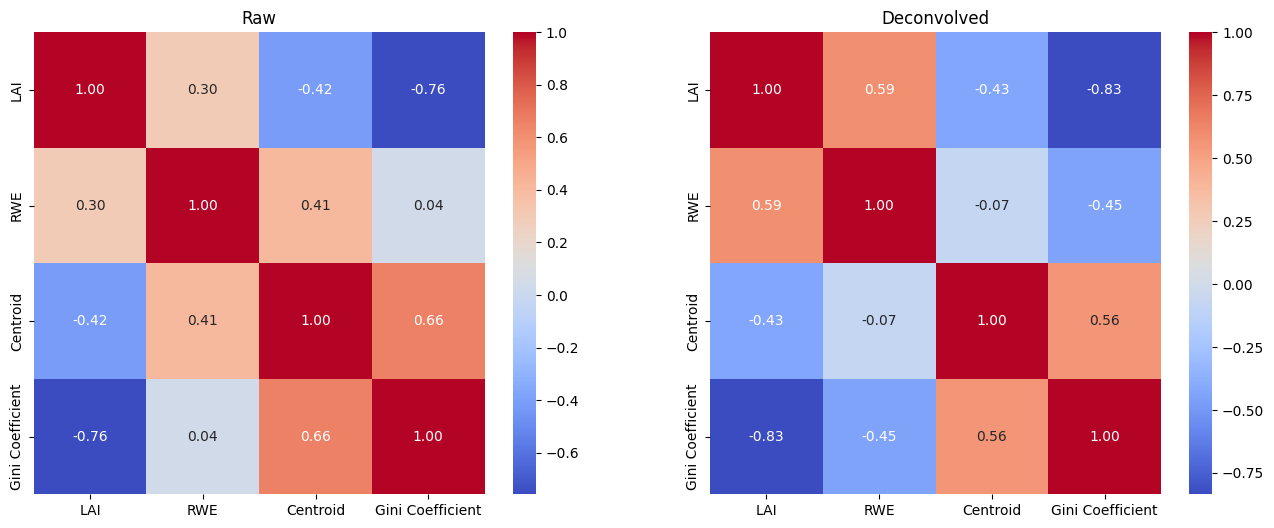

In [24]:
## L. Correlation between LAI and RWE, Centroid, Gini Coefficient

from scipy.stats import pearsonr

# Raw
corr_RWE_raw, _ = pearsonr(RWE_raw, lai_values)
corr_centroid_raw, _ = pearsonr(centroids_raw, lai_values)
corr_GC_raw, _ = pearsonr(Gini_coefficients_raw, lai_values)

# Deconvolved
corr_RWE_decon, _ = pearsonr(RWE_decon, lai_values)
corr_centroid_decon, _ = pearsonr(centroids_decon, lai_values)
corr_GC_decon, _ = pearsonr(Gini_coefficients_decon, lai_values)

print(f"--- Raw Waveform Correlations ---")
print(f"Pearson correlation between LAI and RWE: {corr_RWE_raw:.3f}")
print(f"Pearson correlation between LAI and Centroid: {corr_centroid_raw:.3f}")
print(f"Pearson correlation between LAI and Gini Coefficient: {corr_GC_raw:.3f}")

print(f"\n--- Deconvolved Waveform Correlations ---")
print(f"Pearson correlation between LAI and RWE: {corr_RWE_decon:.3f}")
print(f"Pearson correlation between LAI and Centroid: {corr_centroid_decon:.3f}")
print(f"Pearson correlation between LAI and Gini Coefficient: {corr_GC_decon:.3f}")

## Correlation Matrix Heatmap
data_raw = {
    'LAI': lai_values,
    'RWE': RWE_raw,
    'Centroid': centroids_raw,
    'Gini Coefficient': Gini_coefficients_raw
}

data_decon = {
    'LAI': lai_values,
    'RWE': RWE_decon,
    'Centroid': centroids_decon,
    'Gini Coefficient': Gini_coefficients_decon
}

df_raw = pd.DataFrame(data_raw)
df_decon = pd.DataFrame(data_decon)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap for Raw
sns.heatmap(df_raw.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Raw')

# Heatmap for Deconvolved
sns.heatmap(df_decon.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Deconvolved')

plt.show()


In [25]:
## M. OLS model

# Raw
X1_raw = Gini_coefficients_raw
X2_raw = np.log(centroids_raw.astype(float))
X3_raw = np.log(RWE_raw.astype(float))
Y = lai_values

X_raw = np.column_stack((X1_raw, X2_raw, X3_raw))
X_raw = sm.add_constant(X_raw) 
model_raw = sm.OLS(Y, X_raw).fit()

# Deconvolved
X1_decon = Gini_coefficients_decon
X2_decon = np.log(centroids_decon.astype(float))
X3_decon = np.log(RWE_decon.astype(float))

X_decon = np.column_stack((X1_decon, X2_decon, X3_decon))
X_decon = sm.add_constant(X_decon) 
model_decon = sm.OLS(Y, X_decon).fit()

# Print model summaries
print("Raw data")
print(model_raw.summary())

print("\n Deconvolved data")
print(model_decon.summary())

Raw data
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     5.083
Date:                Thu, 26 Feb 2026   Prob (F-statistic):             0.0353
Time:                        21:17:00   Log-Likelihood:                -1.2604
No. Observations:                  11   AIC:                             10.52
Df Residuals:                       7   BIC:                             12.11
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -34.5956     26.948     -1.284

/Users/rbcis/miniconda3/envs/main/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)
/Users/rbcis/miniconda3/envs/main/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [26]:
## Performance metrics for our model

# Raw Model Metrics
adj_R2_raw = model_raw.rsquared_adj
R2_raw = model_raw.rsquared
MSE_raw = model_raw.mse_resid
RMSE_raw = np.sqrt(MSE_raw)
MAE_raw = np.mean(np.abs(model_raw.resid))
pearson_r_raw = np.corrcoef(model_raw.fittedvalues, Y)[0, 1]

# Deconvolved Model Metrics
adj_R2_decon = model_decon.rsquared_adj
R2_decon = model_decon.rsquared
MSE_decon = model_decon.mse_resid
RMSE_decon = np.sqrt(MSE_decon)
MAE_decon = np.mean(np.abs(model_decon.resid))
pearson_r_decon = np.corrcoef(model_decon.fittedvalues, Y)[0, 1]

# Print results
print(f"Number of Samples: {len(Y)}")

print("\nPerformance Metrics: Raw data")
print(f"Adjusted R²: {adj_R2_raw:.3f}")
print(f"R²: {R2_raw:.3f}")
print(f"MSE: {MSE_raw:.3f}")
print(f"RMSE: {RMSE_raw:.3f}")
print(f"MAE: {MAE_raw:.3f}")
print(f"Pearson r: {pearson_r_raw:.3f}")

print("\nPerformance Metrics: Deconvolved data")
print(f"Adjusted R²: {adj_R2_decon:.3f}")
print(f"R²: {R2_decon:.3f}")
print(f"MSE: {MSE_decon:.3f}")
print(f"RMSE: {RMSE_decon:.3f}")
print(f"MAE: {MAE_decon:.3f}")
print(f"Pearson r: {pearson_r_decon:.3f}")

Number of Samples: 11

Performance Metrics: Raw data
Adjusted R²: 0.551
R²: 0.685
MSE: 0.116
RMSE: 0.340
MAE: 0.227
Pearson r: 0.828

Performance Metrics: Deconvolved data
Adjusted R²: 0.641
R²: 0.749
MSE: 0.092
RMSE: 0.304
MAE: 0.186
Pearson r: 0.865


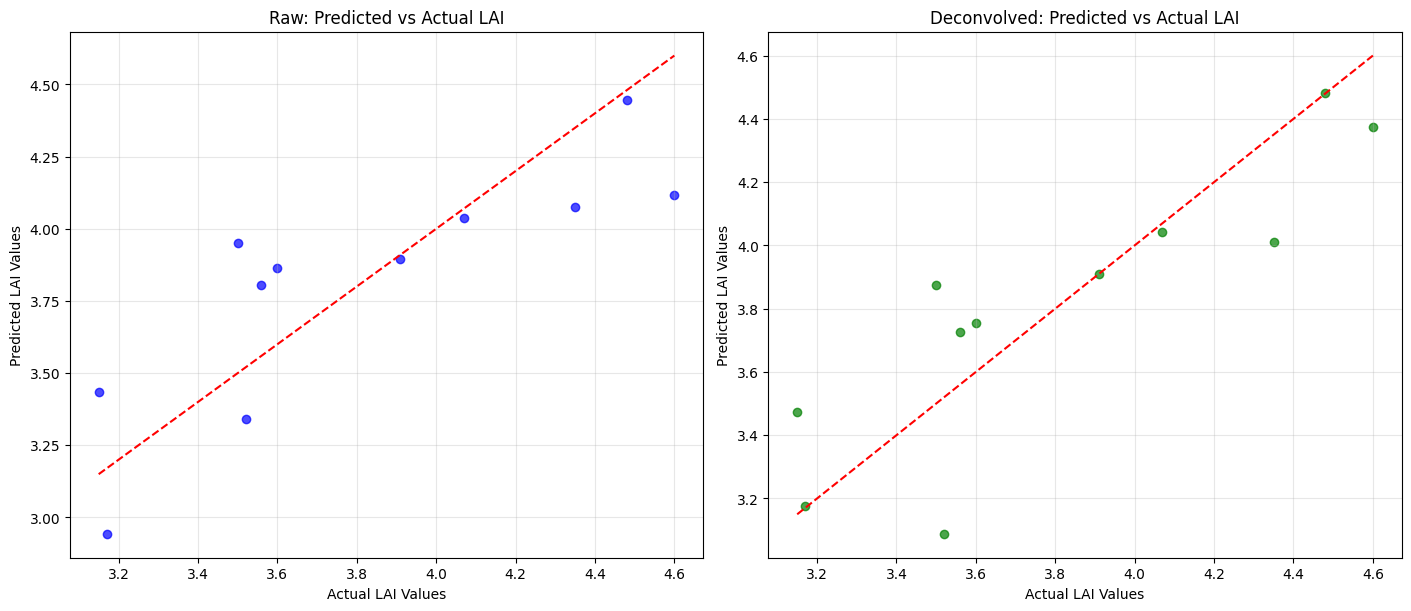

In [27]:
## Plot predicted vs actual LAI values

# Predictions
predicted_lai_raw = model_raw.predict(X_raw)
predicted_lai_decon = model_decon.predict(X_decon)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# Plot for Raw
axes[0].scatter(Y, predicted_lai_raw, color='blue', alpha=0.7)
axes[0].plot([min(Y), max(Y)], [min(Y), max(Y)], color='red', linestyle='--')
axes[0].set_xlabel('Actual LAI Values')
axes[0].set_ylabel('Predicted LAI Values')
axes[0].set_title('Raw: Predicted vs Actual LAI')
axes[0].grid(True, alpha=0.3)

# Plot for Deconvolved
axes[1].scatter(Y, predicted_lai_decon, color='green', alpha=0.7)
axes[1].plot([min(Y), max(Y)], [min(Y), max(Y)], color='red', linestyle='--')
axes[1].set_xlabel('Actual LAI Values')
axes[1].set_ylabel('Predicted LAI Values')
axes[1].set_title('Deconvolved: Predicted vs Actual LAI')
axes[1].grid(True, alpha=0.3)

plt.show()

In [28]:
## N. Ridge regularized regression model

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import LeaveOneOut

# prepare data
x1_raw = np.array(Gini_coefficients_raw)
x2_raw = np.log(np.array(centroids_raw).astype(float))
x3_raw = np.log(np.array(RWE_raw).astype(float))
y = np.array(lai_values)

scaler_raw = StandardScaler()
x_raw = np.column_stack((x1_raw, x2_raw, x3_raw))
x_scaled_raw = scaler_raw.fit_transform(x_raw)

x1_decon = np.array(Gini_coefficients_decon)
x2_decon = np.log(np.array(centroids_decon).astype(float))
x3_decon = np.log(np.array(RWE_decon).astype(float))
scaler_decon = StandardScaler()
x_decon = np.column_stack((x1_decon, x2_decon, x3_decon))
x_scaled_decon = scaler_decon.fit_transform(x_decon)

# Raw
ridge_model_raw = Ridge(alpha=1.0)
ridge_model_raw.fit(x_scaled_raw, y)
y_pred_raw = ridge_model_raw.predict(x_scaled_raw)

# Deconvolved
ridge_model_decon = Ridge(alpha=1.0)
ridge_model_decon.fit(x_scaled_decon, y)
y_pred_decon = ridge_model_decon.predict(x_scaled_decon)

# Metrics calculation
def get_ridge_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    pearson = np.corrcoef(y_true, y_pred)[0, 1]
    return r2, rmse, pearson

r2_r, rmse_r, p_r = get_ridge_metrics(y, y_pred_raw)
r2_d, rmse_d, p_d = get_ridge_metrics(y, y_pred_decon)

print("Ridge regression: raw")
print(f"intercept: {ridge_model_raw.intercept_:.4f}")
print(f"r²: {r2_r:.4f}, rmse: {rmse_r:.4f}, pearson r: {p_r:.4f}")

print("\nRidge regression: deconvolved")
print(f"intercept: {ridge_model_decon.intercept_:.4f}")
print(f"r²: {r2_d:.4f}, rmse: {rmse_d:.4f}, pearson r: {p_d:.4f}")

# Overfit check (loocv)
def check_overfit(x_data, y_data, model_alpha):
    loo = LeaveOneOut()
    mse_cv = []
    for train_idx, test_idx in loo.split(x_data):
        x_tr, x_te = x_data[train_idx], x_data[test_idx]
        y_tr, y_te = y_data[train_idx], y_data[test_idx]
        fold_model = Ridge(alpha=model_alpha)
        fold_model.fit(x_tr, y_tr)
        mse_cv.append((fold_model.predict(x_te)[0] - y_te[0])**2)
    return np.sqrt(np.mean(mse_cv))

rmse_loocv_raw = check_overfit(x_scaled_raw, y, 1.0)
rmse_loocv_decon = check_overfit(x_scaled_decon, y, 1.0)

print("\nOverfitting check: raw")
print(f"training rmse: {rmse_r:.4f}, loocv rmse: {rmse_loocv_raw:.4f}")

print("\nOverfitting check: deconvolved")
print(f"training rmse: {rmse_d:.4f}, loocv rmse: {rmse_loocv_decon:.4f}")

Ridge regression: raw
intercept: 3.8100
r²: 0.6805, rmse: 0.2734, pearson r: 0.8274

Ridge regression: deconvolved
intercept: 3.8100
r²: 0.7441, rmse: 0.2447, pearson r: 0.8642

Overfitting check: raw
training rmse: 0.2734, loocv rmse: 0.3914

Overfitting check: deconvolved
training rmse: 0.2447, loocv rmse: 0.3779


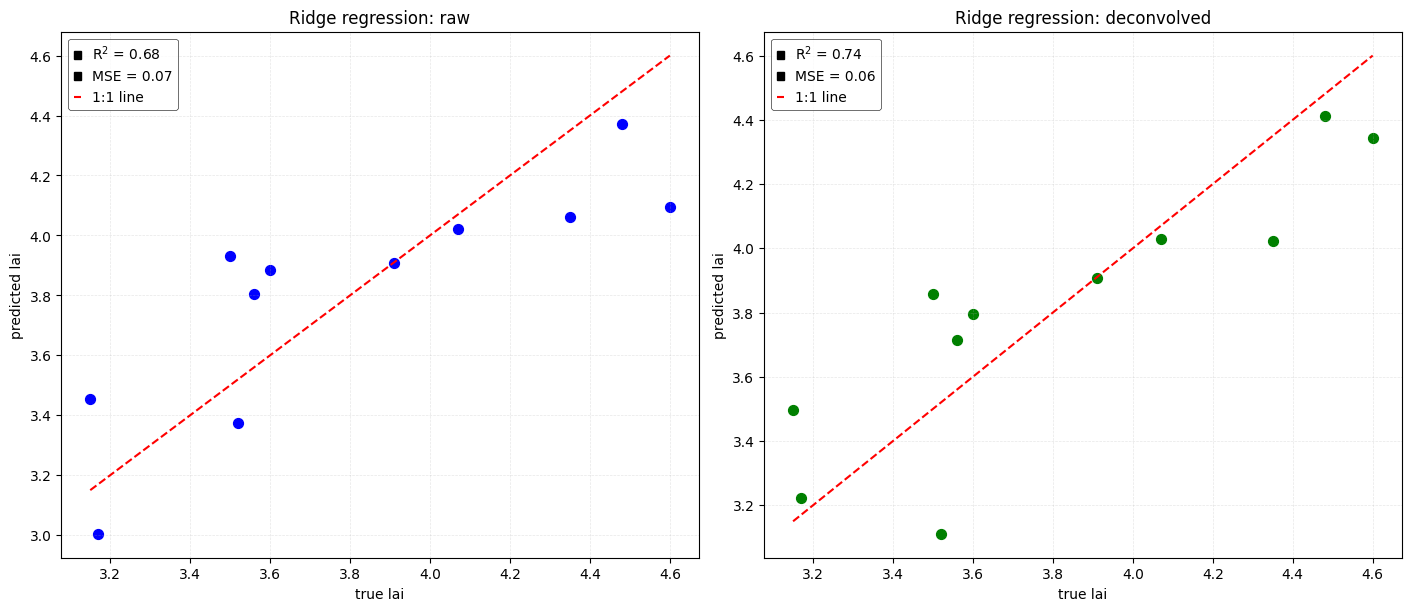

In [29]:
## Plot predicted vs actual LAI values for Ridge Regression


fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# plot for raw
axes[0].scatter(y, y_pred_raw, alpha=1, color='blue', s=50, edgecolors='blue', linewidth=1)
line1to1_raw = axes[0].plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='1:1 line')[0]
axes[0].set_xlabel('true lai')
axes[0].set_ylabel('predicted lai')
axes[0].set_title('Ridge regression: raw')
axes[0].grid(True, linestyle='--', alpha=0.3, linewidth=0.5)

pms_raw = [
    mpatches.Patch(color='black', label=f'R$^2$ = {r2_r:.2f}'),
    mpatches.Patch(color='black', label=f'MSE = {rmse_r**2:.2f}'), 
    line1to1_raw
]
leg_raw = axes[0].legend(handles=pms_raw, loc='upper left', handleheight=0.5, handlelength=0.5)
leg_raw.get_frame().set_edgecolor('black')
leg_raw.get_frame().set_linewidth(0.5)

# plot for deconvolved
axes[1].scatter(y, y_pred_decon, alpha=1, color='green', s=50, edgecolors='green', linewidth=1)
line1to1_decon = axes[1].plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='1:1 line')[0]
axes[1].set_xlabel('true lai')
axes[1].set_ylabel('predicted lai')
axes[1].set_title('Ridge regression: deconvolved')
axes[1].grid(True, linestyle='--', alpha=0.3, linewidth=0.5)

pms_decon = [
    mpatches.Patch(color='black', label=f'R$^2$ = {r2_d:.2f}'),
    mpatches.Patch(color='black', label=f'MSE = {rmse_d**2:.2f}'), 
    line1to1_decon
]
leg_decon = axes[1].legend(handles=pms_decon, loc='upper left', handleheight=0.5, handlelength=0.5)
leg_decon.get_frame().set_edgecolor('black')
leg_decon.get_frame().set_linewidth(0.5)
# plt.savefig('../../Real_LVIS_samples_test_empirical_model_v2.pdf', dpi=600, bbox_inches='tight', format='pdf')
# plt.savefig('../../Real_LVIS_samples_test_empirical_model_v2.png', dpi=600, bbox_inches='tight', format='png')
plt.show()

Extracting and processing LVIS waveforms within the defined bounds

Opening LVISC1B_GEDI2021_0806_R2112_049718.h5...
Found 1534 waveforms within the bounds.


Processing Footprints: 100%|██████████| 1534/1534 [00:44<00:00, 34.25it/s]



Opening LVISC1B_GEDI2021_0806_R2112_051257.h5...
Found 0 waveforms within the bounds.

Total valid footprints processed successfully: 1534


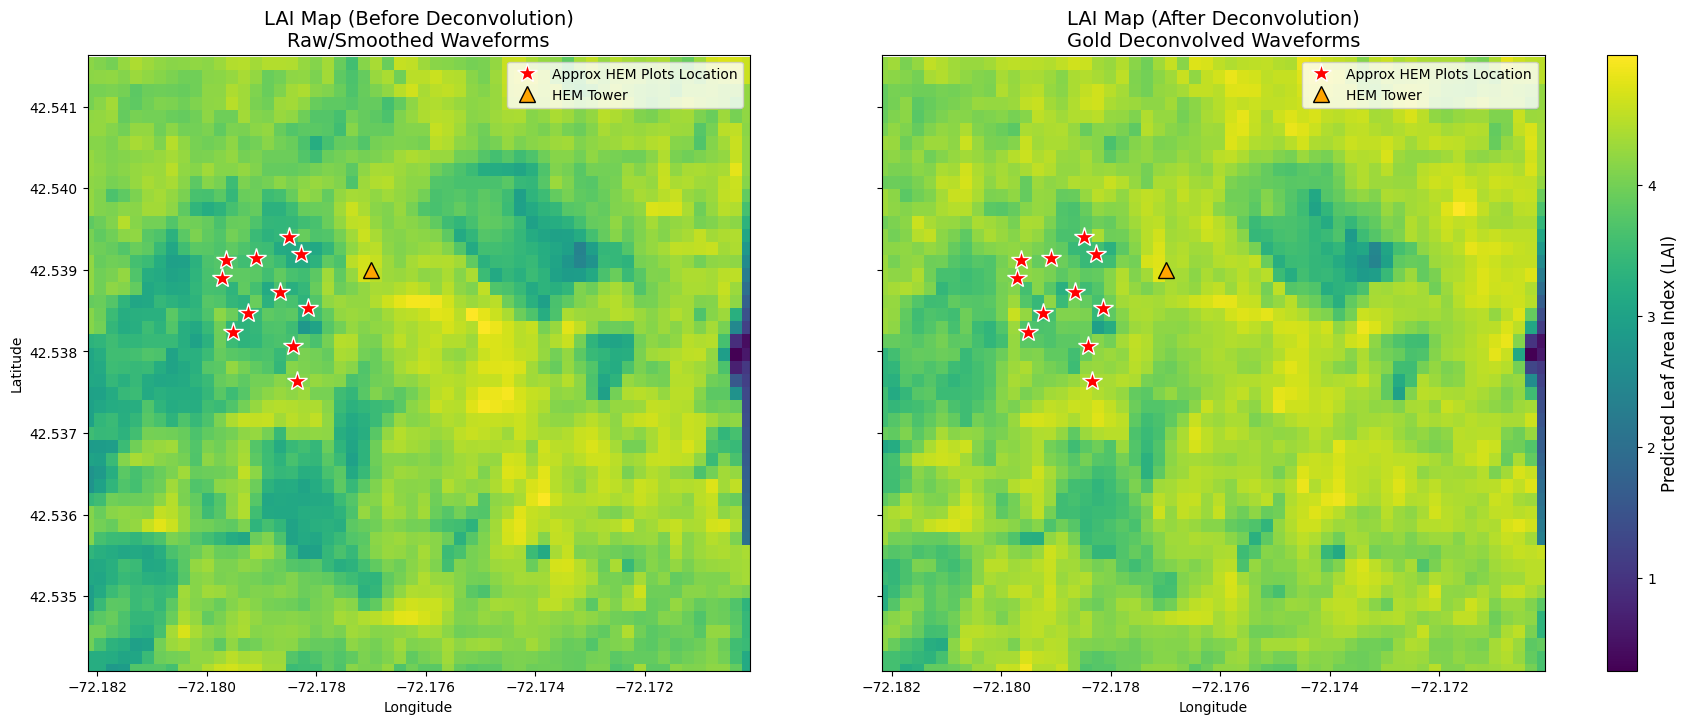

In [35]:
## M. Now use the model to map the LAI all over the defined bound of Harvard Forest

"""

This code can be run independently of all above analysis except the part of importing libraries and LVIS files. 
To run our models for different dataset do this changes:

1. lvis_files: Update the list with the paths to your new LVIS .h5 files.
2. base_min_lon, base_max_lon, base_min_lat, base_max_lat: Change these coordinates to the bounding box of your new study area.
3. target_shots & hem_tower_location: Update these with shot numbers and landmark coordinates for your new site, or leave them empty/commented out if not needed.
4. smoothed_avg_bare_ground_rx: Recalculate this reference bare ground waveform using a shot from your new dataset, as laser pulse shapes vary between flights.

""" 


from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
from tqdm import tqdm  

# Helper function to extract metrics
def extract_model_features(waveform):
    waveform_corrected = np.maximum(waveform - np.min(waveform), 0)
    total_energy = np.sum(waveform_corrected)
    if total_energy <= 0: return None
        
    x = np.arange(len(waveform_corrected))
    centroid = np.sum(x * waveform_corrected) / total_energy
    
    # safeguard against log(0)
    if centroid <= 0: return None
    
    peaks, _ = find_peaks(waveform_corrected, height=np.max(waveform_corrected) * 0.05)
    derivative = np.diff(waveform_corrected)
    
    first_inflection_point, last_inflection_point = None, None
    if len(peaks) > 0:
        last_peak = peaks[-1]
        for i in range(last_peak + 1, len(derivative)):
            if derivative[i] == 0.0:
                last_inflection_point = i
                break
        for i in range(len(derivative)):
            if derivative[i] > 0.0:
                first_inflection_point = i
                break

    if first_inflection_point is not None and last_inflection_point is not None:
        waveform_clipped = waveform_corrected[first_inflection_point:last_inflection_point+1]
    else:
        waveform_clipped = waveform_corrected

    waveform_reversed = waveform_clipped[::-1]
    cumulative_energy = np.cumsum(waveform_reversed)
    total_energy_rev = np.sum(waveform_reversed)

    if total_energy_rev <= 0: return None

    s = 0.05
    RH_levels = np.arange(0, 1 + s, s)
    RHs = np.array([np.searchsorted(cumulative_energy, level * total_energy_rev) for level in RH_levels]) 
    
    lorentz_height_values = np.cumsum(RHs * 0.15)
    max_lhv = np.max(lorentz_height_values)
    if max_lhv <= 0: return None
    
    lorentz_height_values = lorentz_height_values / max_lhv
    gini = calculate_gini_coeff(lorentz_height_values, s)
    
    return [gini, np.log(centroid), np.log(total_energy)]

# Extract and Process LVIS Files 
lons, lats = [], []
lai_before_decon = []
lai_after_decon = []

# Diagnostics trackers
debug_stats = {'empty_raw': 0, 'empty_decon': 0, 'out_of_bounds': 0, 'exceptions': 0}
first_exception = None

# These shots were used for the ground plots pairing
target_shots = [2276855, 2276654, 2276454, 2276773, 2276851, 2276970, 2277169, 2277252, 2277172, 2277174, 2277049]
hem_tower_location = [-72.177, 42.539]   # "HEM" tower location
target_lons, target_lats, target_labels = [], [], []

# Defining bounds of the map
base_min_lon, base_max_lon = -72.181566, -72.170686
base_min_lat, base_max_lat = 42.534536, 42.541188
buffer_meters = 50.0       # buffer from base boundary region
lat_buffer_deg = buffer_meters / 111320.0
lon_buffer_deg = buffer_meters / (111320.0 * np.cos(np.radians(42.54)))
bounds = {
    'min_lon': base_min_lon - lon_buffer_deg, 
    'max_lon': base_max_lon + lon_buffer_deg, 
    'min_lat': base_min_lat - lat_buffer_deg,  
    'max_lat': base_max_lat + lat_buffer_deg
}

subsample_rate = 1    # sample every 'x' waveforms

print("Extracting and processing LVIS waveforms within the defined bounds")
for lvis_file in lvis_files:
    print(f"\nOpening {lvis_file}...")
    try:
        with h5py.File(lvis_file, 'r') as f:
            glon = np.array(f['LON0']).flatten()
            glat = np.array(f['LAT0']).flatten()
            rxwave = np.array(f['RXWAVE'])
            sigmean = np.array(f['SIGMEAN']).flatten()
            shot_nums = np.array(f['SHOTNUMBER']).flatten()
            # Normalize Longitude
            glon = np.where(glon > 180, glon - 360, glon)
            
            # Find and save target shot coordinates
            match_mask = np.isin(shot_nums, target_shots)
            match_indices = np.where(match_mask)[0]
            for m_idx in match_indices:
                target_lons.append(glon[m_idx])
                target_lats.append(glat[m_idx])
                target_labels.append(str(shot_nums[m_idx]))
            
            # Spatial Masking to get valid_indices
            spatial_mask = (glon >= bounds['min_lon']) & (glon <= bounds['max_lon']) & \
                           (glat >= bounds['min_lat']) & (glat <= bounds['max_lat'])
            
            valid_indices = np.where(spatial_mask)[0][::subsample_rate]
            print(f"Found {len(valid_indices)} waveforms within the bounds.")
            
            if len(valid_indices) == 0:
                continue 
            
            for idx in tqdm(valid_indices, desc="Processing Footprints"):
                try: 
                    raw_wave = rxwave[idx]
                    sm_noise = sigmean[idx]
                    
                    if np.sum(raw_wave) <= 0: continue
                        
                    # A. Raw/Smoothed Processing
                    rx_clean = np.array(raw_wave - sm_noise, dtype=np.float64)
                    smoothed_wave = gaussian_filter1d(rx_clean, sigma=10.0)
                    
                    smoothed_clipped = smoothed_wave[400:800]
                    
                    features_raw = extract_model_features(smoothed_clipped)
                    if features_raw is None: 
                        debug_stats['empty_raw'] += 1
                        continue
                    
                    # B. Gold Deconvolution Processing
                    deconv_wave = boosted_gold_deconvolution(
                        P_t=smoothed_wave,  # FIXED: Capital P_t
                        R_t=smoothed_avg_bare_ground_rx,  # FIXED: Capital R_t
                        num_iterations=500, 
                        num_repetitions=1, 
                        boosting_coefficient=1, 
                        positivity=True
                    )
                    deconv_clipped = deconv_wave[400:800]
                    
                    features_decon = extract_model_features(deconv_clipped)
                    if features_decon is None: 
                        debug_stats['empty_decon'] += 1
                        continue
                    
                    # C. Predict LAI using separate models and scalers (fixed shapes)
                    x_raw_features = np.array(features_raw).reshape(1, -1)
                    x_decon_features = np.array(features_decon).reshape(1, -1)
                    
                    x_raw_scaled = scaler_raw.transform(x_raw_features) 
                    x_decon_scaled = scaler_decon.transform(x_decon_features) 
                    
                    pred_raw = ridge_model_raw.predict(x_raw_scaled)[0]
                    pred_decon = ridge_model_decon.predict(x_decon_scaled)[0]
                    
                    # Using a safe, wide filter just to make sure data is capturing
                    if -10 <= pred_raw <= 50 and -10 <= pred_decon <= 50:
                        lons.append(glon[idx])
                        lats.append(glat[idx])
                        lai_before_decon.append(max(0, pred_raw))
                        lai_after_decon.append(max(0, pred_decon))
                    else:
                        debug_stats['out_of_bounds'] += 1
                        
                except Exception as e:
                    debug_stats['exceptions'] += 1
                    if first_exception is None:
                        first_exception = e
                    continue
                    
    except Exception as e:
        print(f"Failed to read file {lvis_file}: {e}")

map_lons = np.array(lons)
map_lats = np.array(lats)
lai_before = np.array(lai_before_decon)
lai_after = np.array(lai_after_decon)

print(f"\nTotal valid footprints processed successfully: {len(map_lons)}")

# 3. Spatial Interpolation & Mapping
if len(map_lons) > 5: 
    target_resolution_m = 18.0  # 25/sqrt(2) = 18m pixel; largest square within circular footprint
    deg_per_meter_lat = 1.0 / 111320.0
    mean_lat_rad = np.radians(42.54)
    deg_per_meter_lon = 1.0 / (111320.0 * np.cos(mean_lat_rad))
    
    grid_res_lon = target_resolution_m * deg_per_meter_lon
    grid_res_lat = target_resolution_m * deg_per_meter_lat
    
    grid_lon, grid_lat = np.mgrid[bounds['min_lon']:bounds['max_lon']:grid_res_lon, 
                                  bounds['min_lat']:bounds['max_lat']:grid_res_lat]
    
    grid_before_near = griddata((map_lons, map_lats), lai_before, (grid_lon, grid_lat), method='nearest')
    grid_before = griddata((map_lons, map_lats), lai_before, (grid_lon, grid_lat), method='linear')
    grid_before = np.where(np.isnan(grid_before), grid_before_near, grid_before)
    
    grid_after_near = griddata((map_lons, map_lats), lai_after, (grid_lon, grid_lat), method='nearest')
    grid_after = griddata((map_lons, map_lats), lai_after, (grid_lon, grid_lat), method='linear')
    grid_after = np.where(np.isnan(grid_after), grid_after_near, grid_after)
    
    smoothed_before = gaussian_filter(grid_before, sigma=0.0) 
    smoothed_after = gaussian_filter(grid_after, sigma=0.0)
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True, sharey=True)

    im1 = axes[0].pcolormesh(grid_lon, grid_lat, smoothed_before, shading='auto', cmap='viridis')
    axes[0].set_title('LAI Map (Before Deconvolution)\nRaw/Smoothed Waveforms', fontsize=14)
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')

    im2 = axes[1].pcolormesh(grid_lon, grid_lat, smoothed_after, shading='auto', cmap='viridis')
    axes[1].set_title('LAI Map (After Deconvolution)\nGold Deconvolved Waveforms', fontsize=14)
    axes[1].set_xlabel('Longitude')
    axes[0].set_xlim(bounds['min_lon'], bounds['max_lon'])
    axes[0].set_ylim(bounds['min_lat'], bounds['max_lat'])

    # Overlay shots and tower locations
    for ax in axes:
        for t_lon, t_lat, label in zip(target_lons, target_lats, target_labels):
            ax.plot(t_lon, t_lat, marker='*', color='red', markersize=15, 
                    markeredgecolor='white', linewidth=0, label='Approx HEM Plots Location')
        ax.plot(hem_tower_location[0], hem_tower_location[1], marker='^', color='orange', 
                markersize=12, markeredgecolor='black', linewidth=0, label="HEM Tower")
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles)) 
        ax.legend(by_label.values(), by_label.keys())

    cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
    cbar.set_label('Predicted Leaf Area Index (LAI)', fontsize=12)
    plt.show()
else:
    print("Not enough points found to generate a map.")